# Hier-COS Output Analysis

This notebook analyzes training/test artifacts in `/scratch/g.saggini1/outputs/` and compares Hier-COS variants across datasets.

Default setup:
- baselines: `hiercos_<dataset>_global_softmax_ce_reg_baseline_<weight>` with `equal` and `kl_leaf`
- orthogonalize-all lex runs: `hiercos_<dataset>_global_softmax_ce_reg_lex_orthogonalize_all_<mode>`
- conflict-only lex runs: `hiercos_<dataset>_global_softmax_ce_reg_lex_conflict_only_<mode>`
- coarse-first transform ablations: `hiercos_<dataset>_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_transform_<transform>`
- targeted normalization ablation: run with `model.loss=level_softmax_ce_reg` using explicit output directories

It includes:
- validation curves for `FPA`, `weighted AP`, `TICE`, and `AHD`,
- per-level validation top-down/independent accuracy curves,
- training loss comparisons (`total`, `ce`, `reg`, `kl`, and exact weighted `loss_level_*` when available),
- optional projection/gradient diagnostics when those metrics are present in logs,
- final test comparison tables with deltas versus dataset baseline.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HierCosAnalysis,
    HCastAnalysisConfig as HierCosAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
INCLUDE_BASELINES = True
BASELINE_COLOR = "#243ab4"

BASELINE_BY_DATASET = {
    'cifar-100': {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'cub-200-2011': {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'fgvc-aircraft': {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'inat19': {'run_dir': 'hiercos_inat19_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
}

MANUAL_RUNS = [
    # Equal-weight non-lex baselines
    {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    {'run_dir': 'hiercos_inat19_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},

    # Orthogonalize-all lex runs
    *[
        {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}',
         'label': f'Hier-COS global softmax {mode} orthogonalize_all'}
        for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
        for mode in ('coarse_first', '')
    ],

    # Conflict-only lex runs
    *[
        {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_conflict_only_{mode}',
         'label': f'Hier-COS global softmax {mode} conflict_only'}
        for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
        for mode in ('coarse_first', 'fine_first')
    ],

    # Uncomment after running transform ablations.
    *[
        {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_{transform}',
         'label': f'Hier-COS global softmax coarse_first {transform}'}
        for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
        for transform in ('bn_linear', 'final_only')
    ],

    # Add targeted level-softmax runs here after launching with model.loss=level_softmax_ce_reg.
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [3]:
config = HierCosAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HierCosAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_global_softmax_ce_reg_baseline_equal
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_conflict_only_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex

## Hier-COS Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


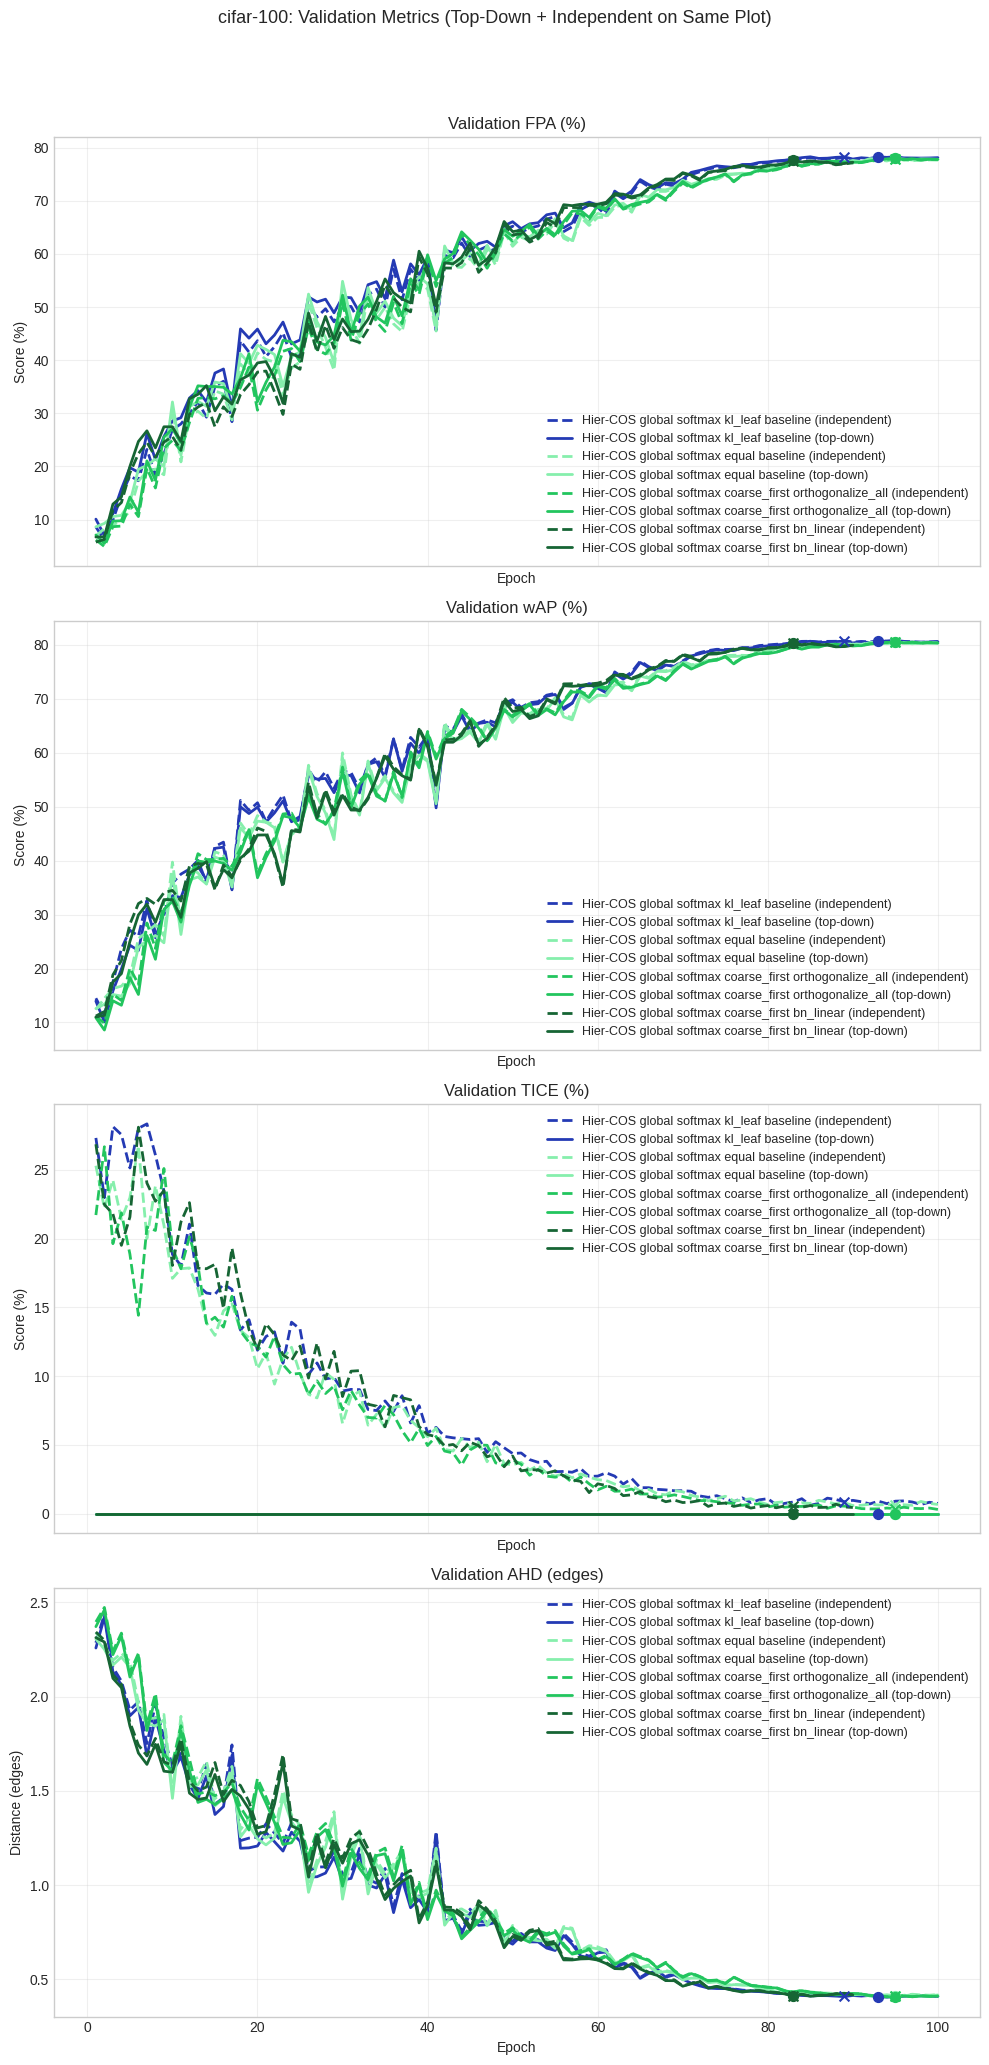

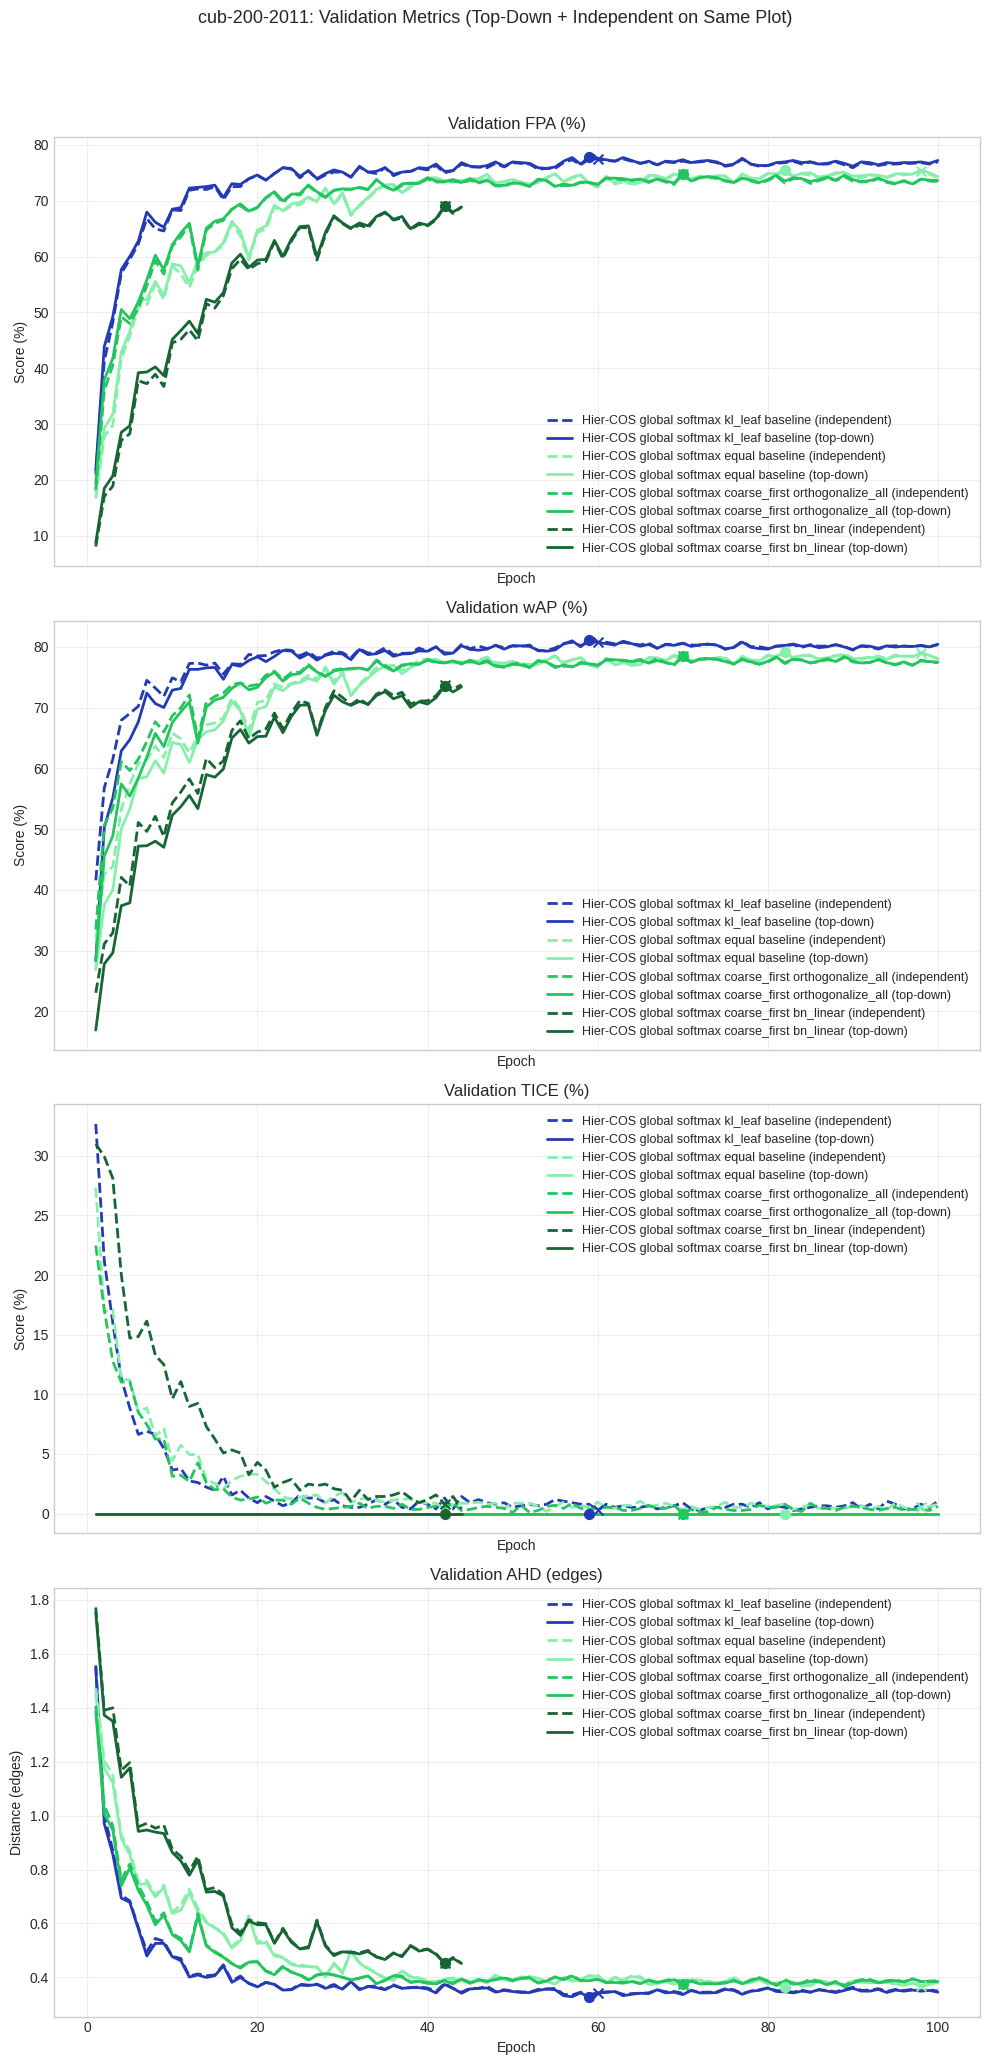

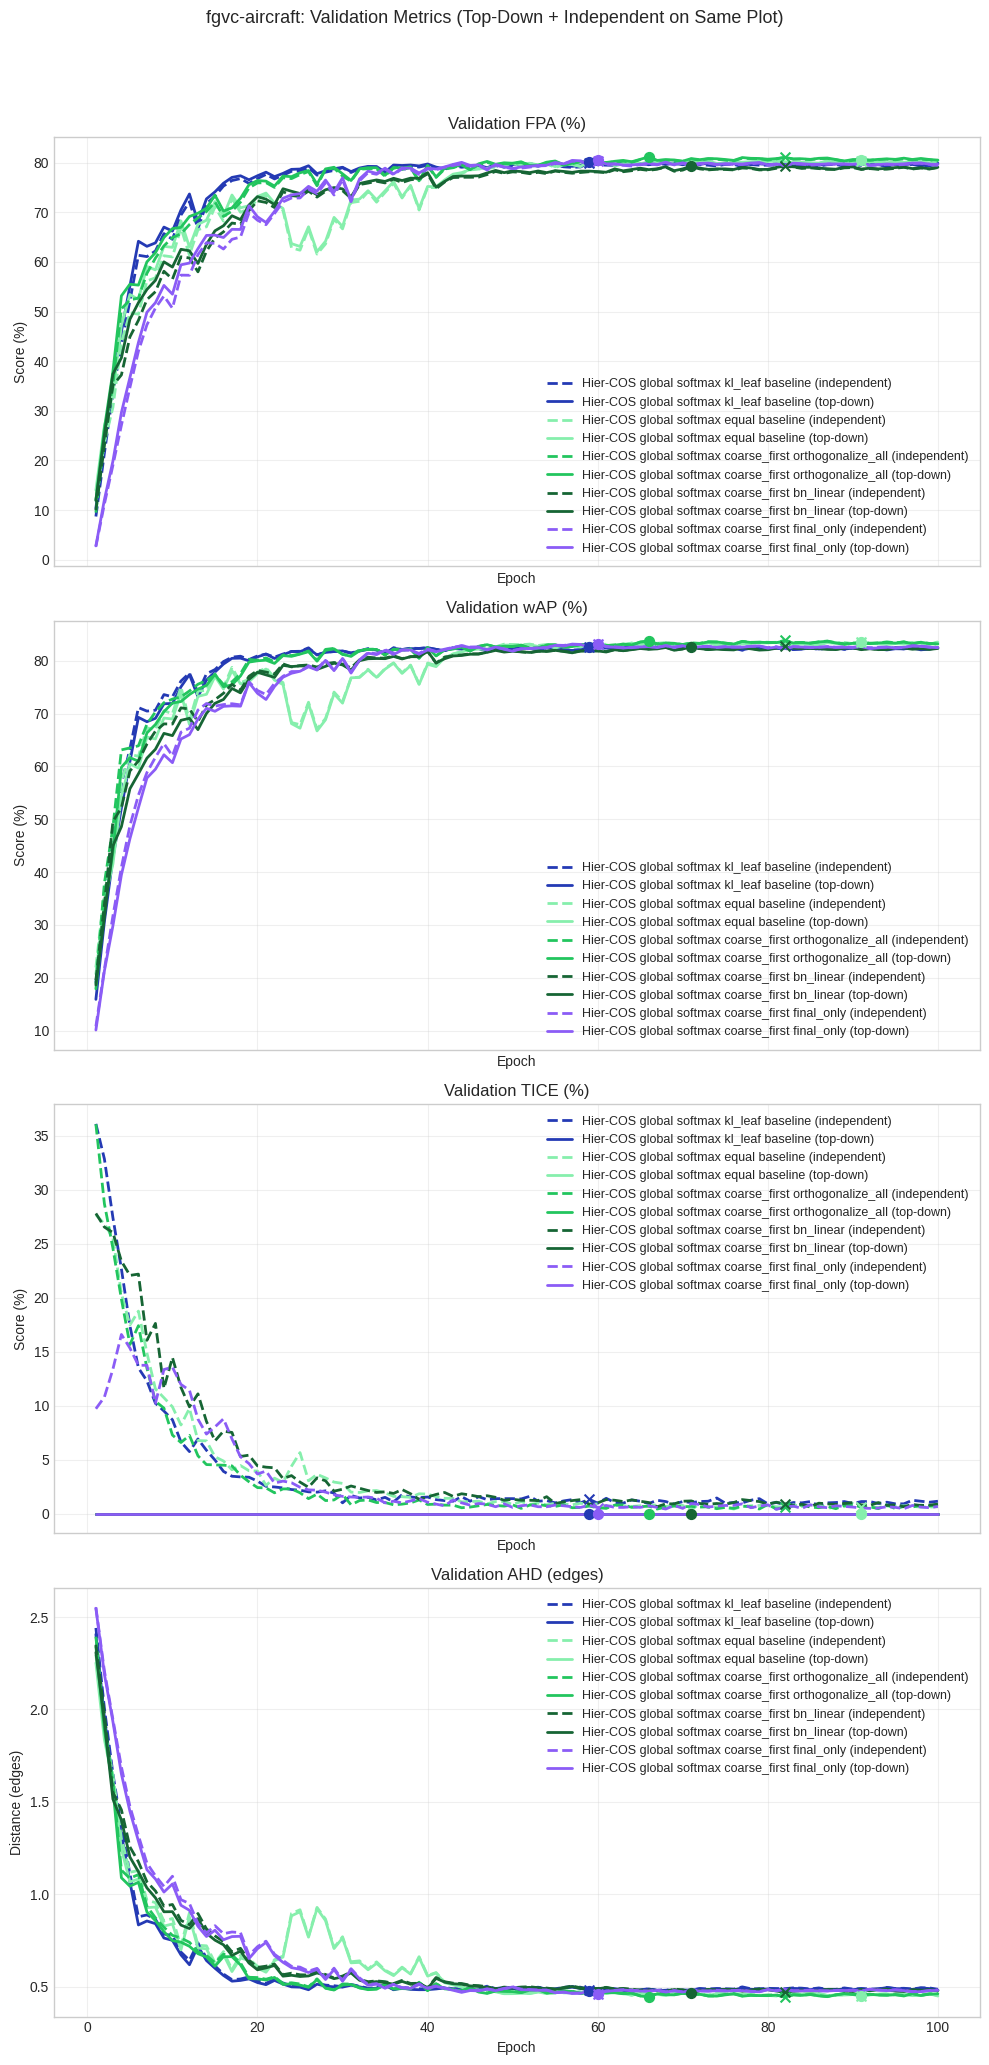

In [4]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (If Available)

This section visualizes projection diagnostics logged in `val_metrics` and `train_metrics` (when available):
- `proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, `proj_mode_intrinsic_soft`

For standard Hier-COS runs these keys may be absent; in that case the section prints a per-dataset skip message.


In [5]:
analysis.plot_projection_diagnostics()


[cifar-100] No projection diagnostics found in selected runs.
[cub-200-2011] No projection diagnostics found in selected runs.
[fgvc-aircraft] No projection diagnostics found in selected runs.


## Training Loss Comparison

This section compares aggregate losses (`total`, `ce`, `reg`, and exact `kl` for `kl_reg`) and exact weighted per-level objectives (`loss_level_*`, when available).


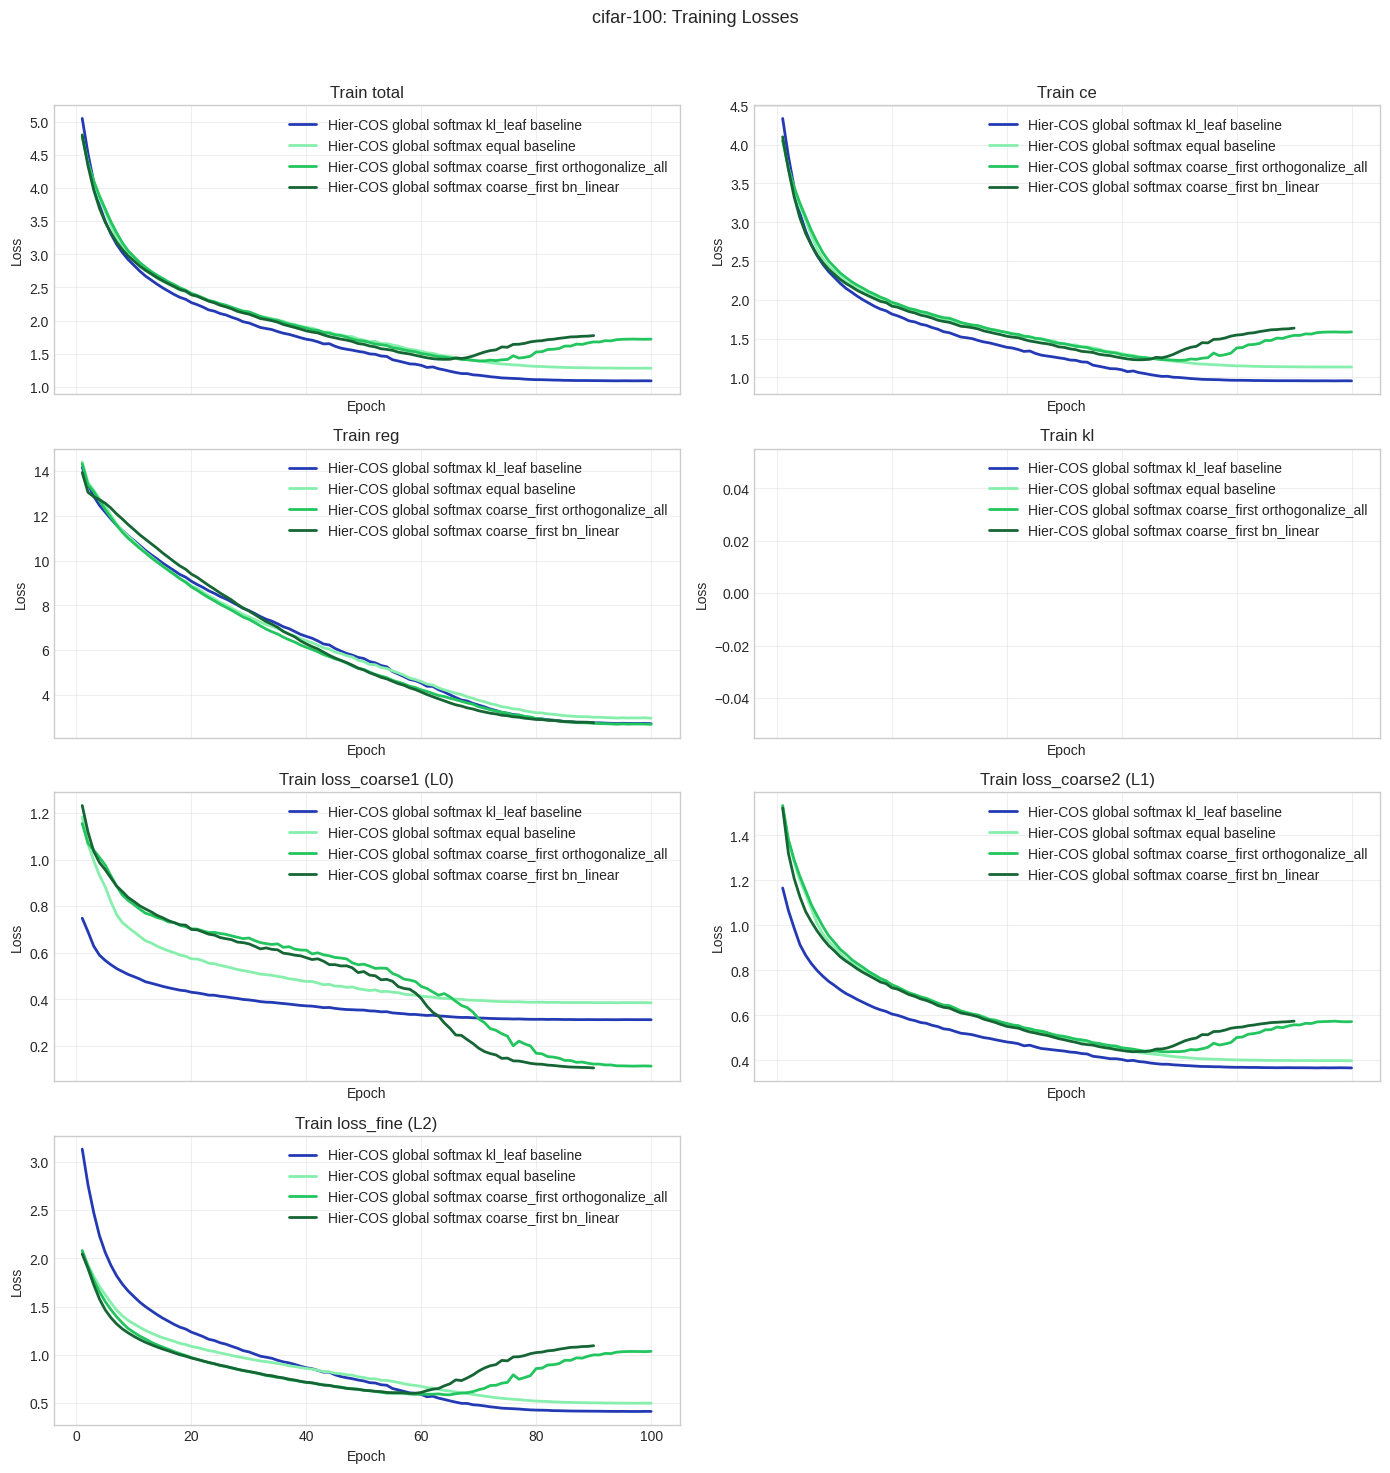

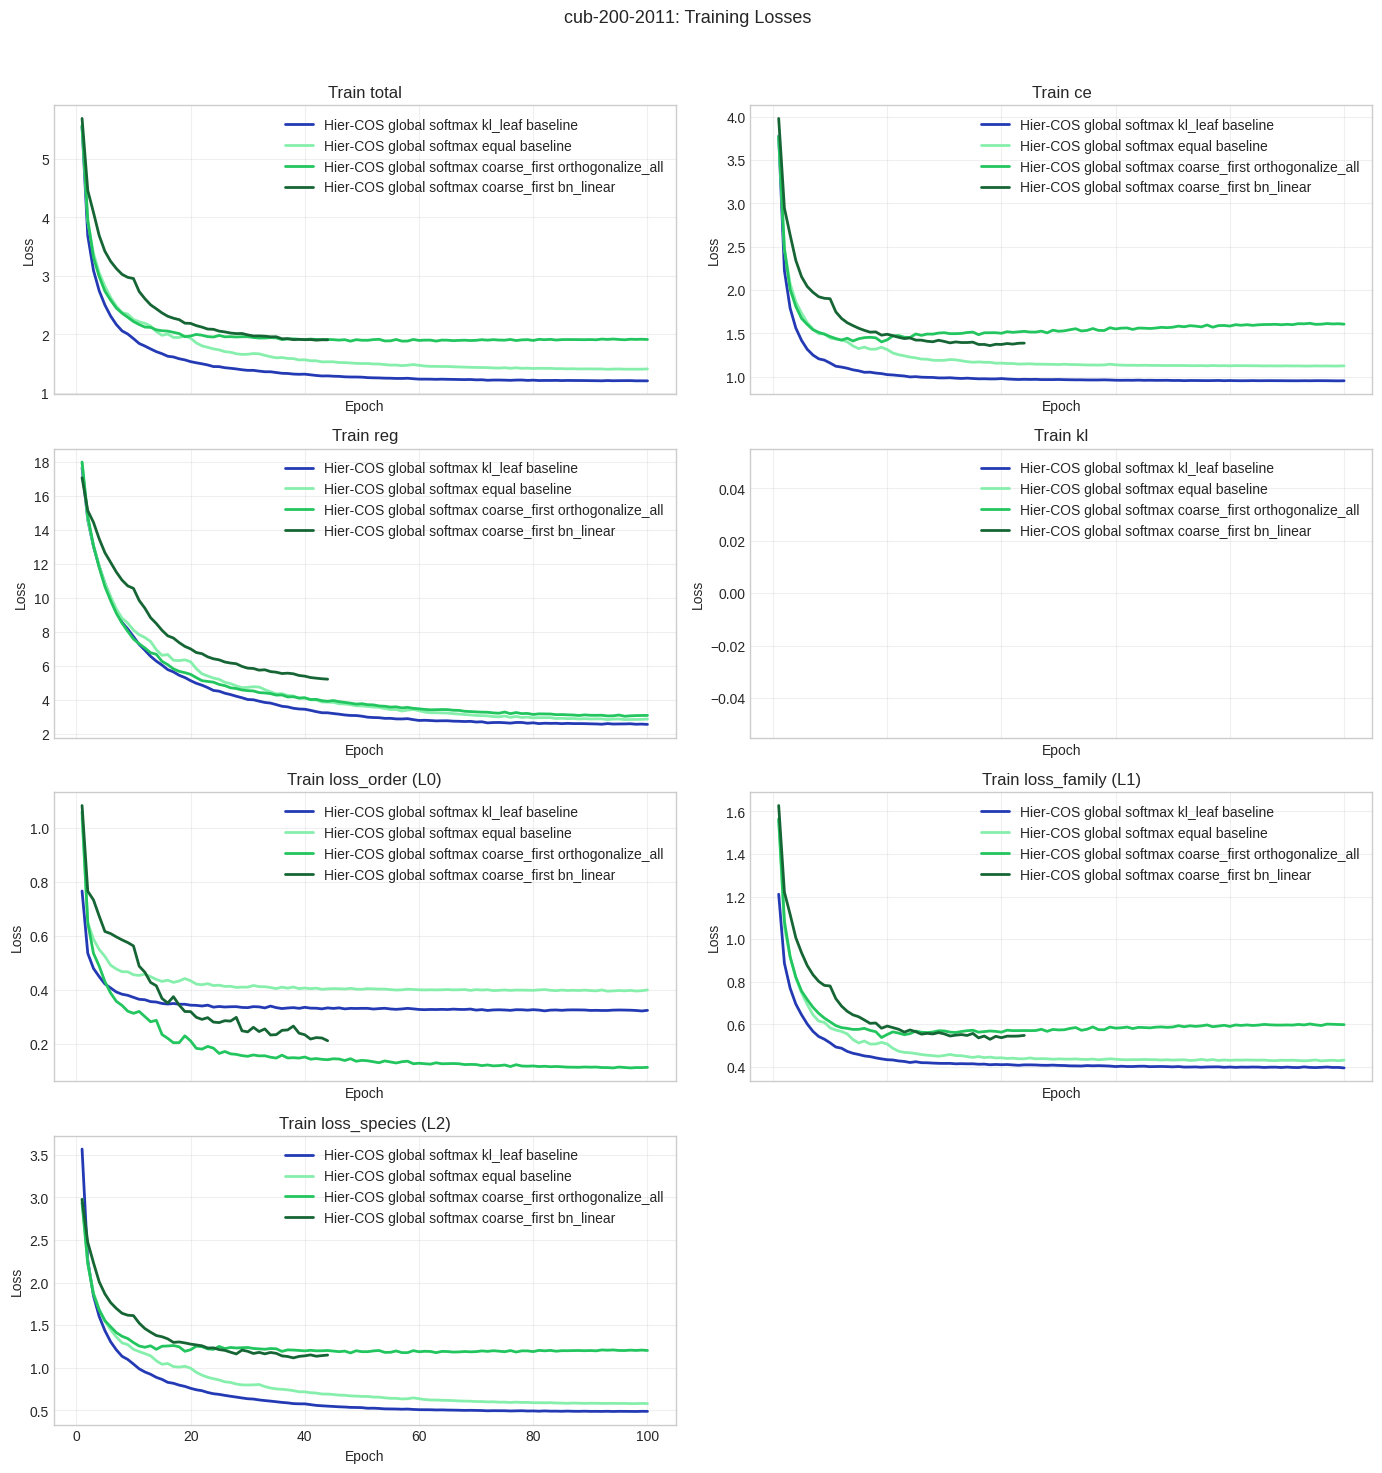

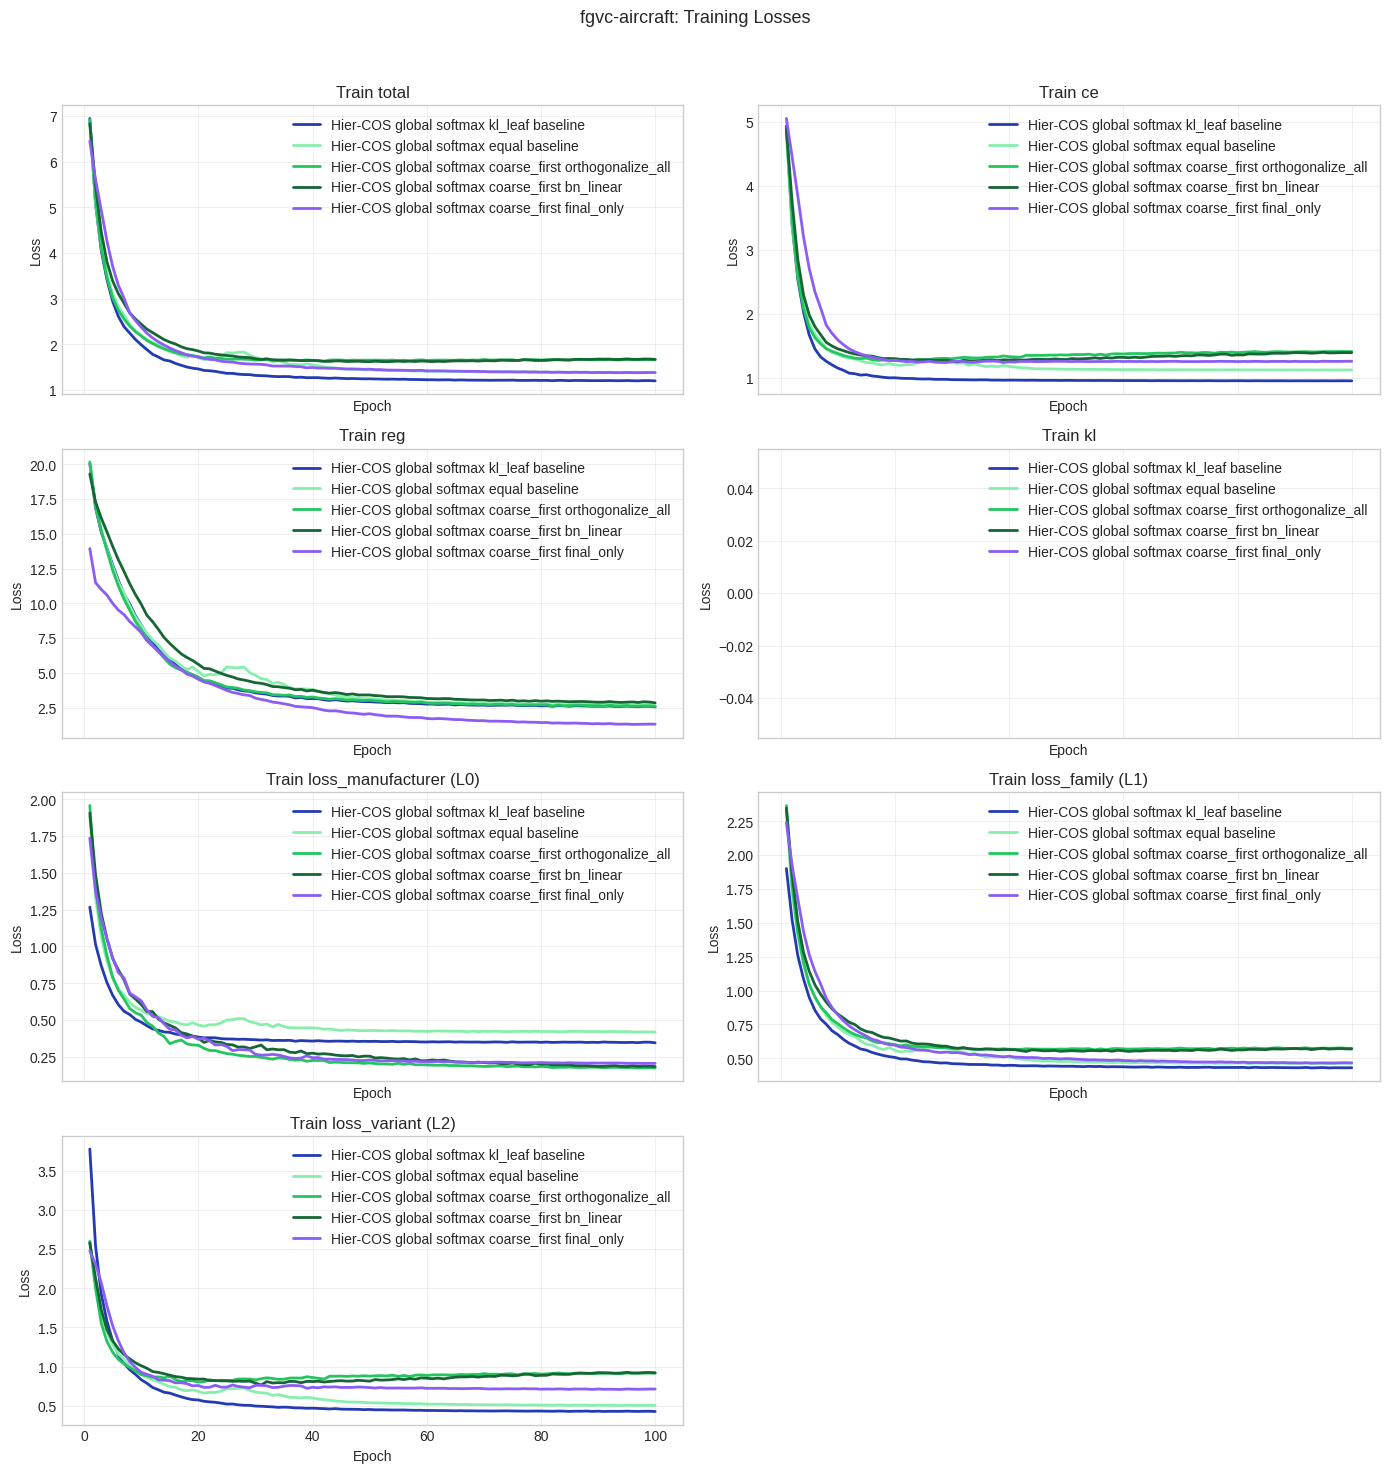

In [6]:
analysis.plot_training_losses(aggregate_loss_keys=['total', 'ce', 'reg', 'kl'])


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



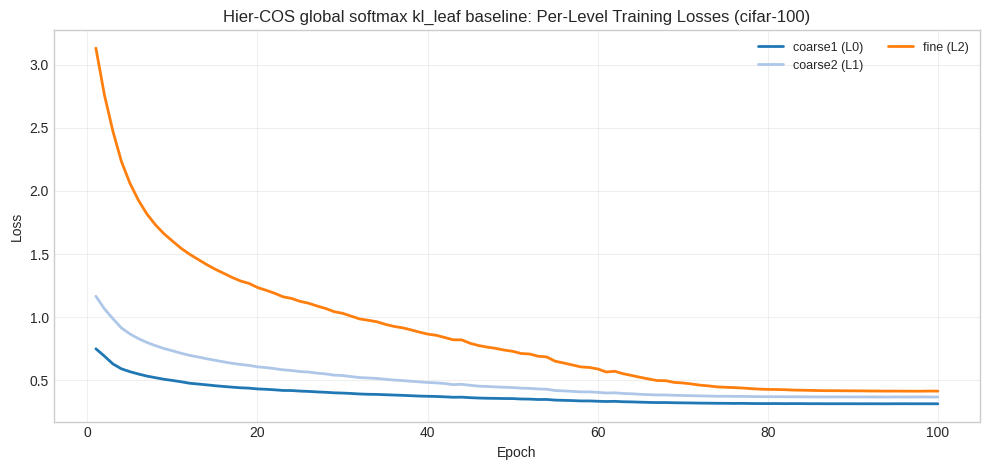

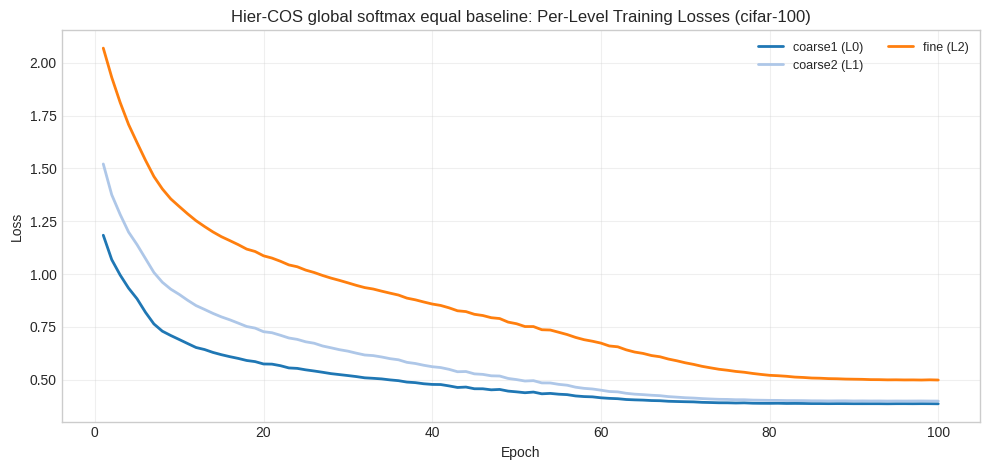

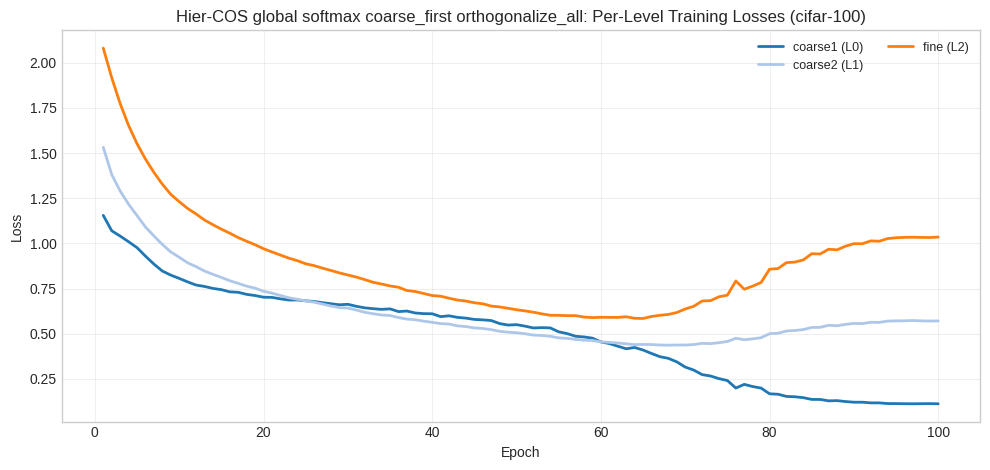

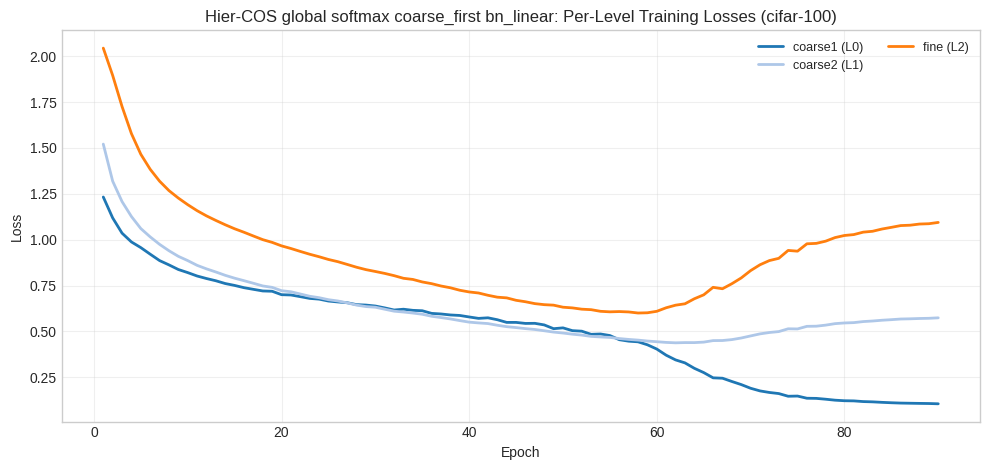

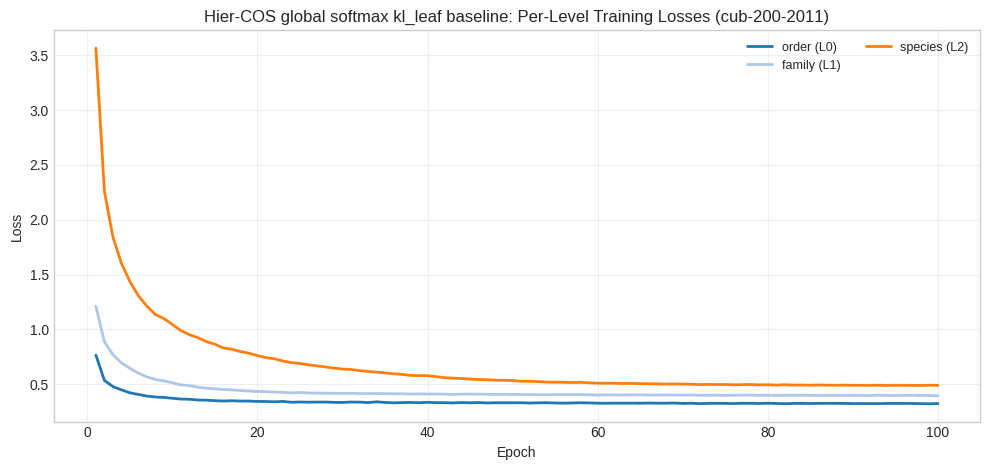

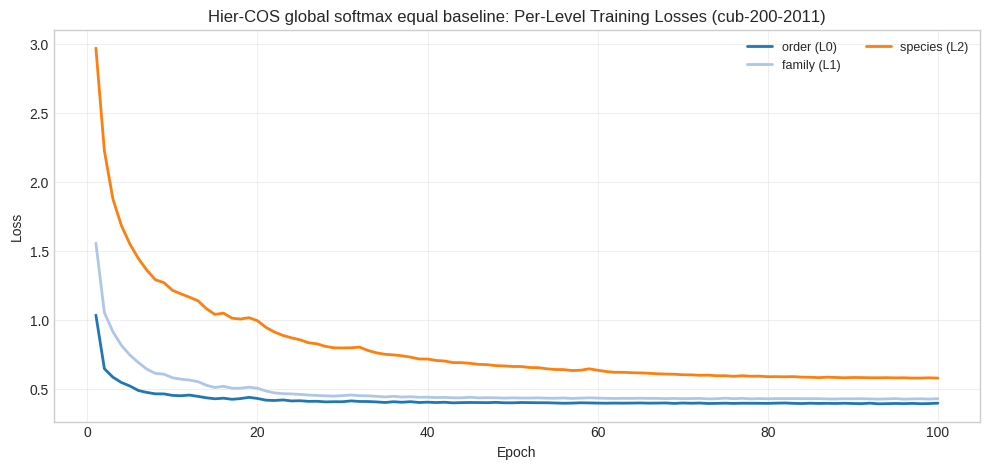

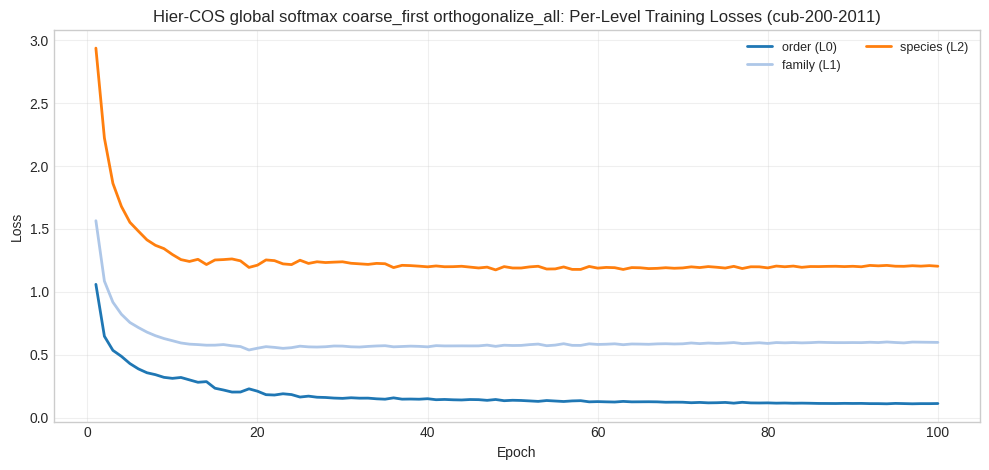

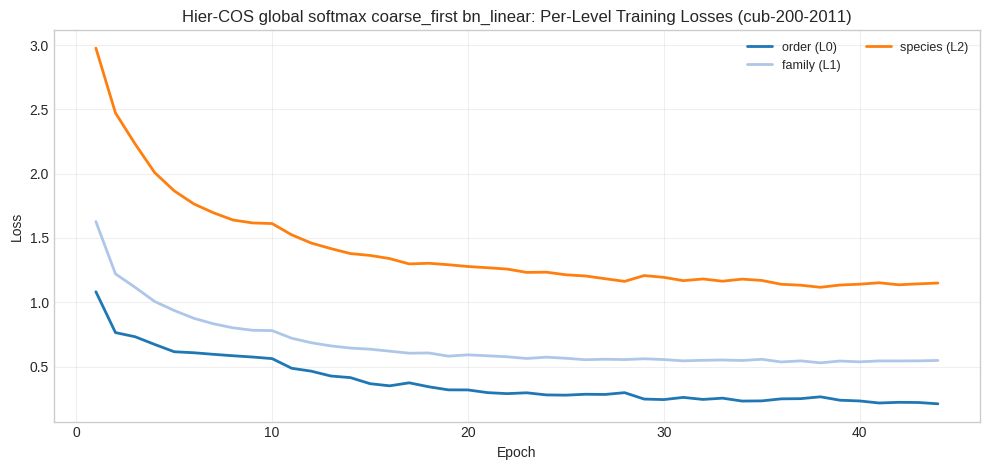

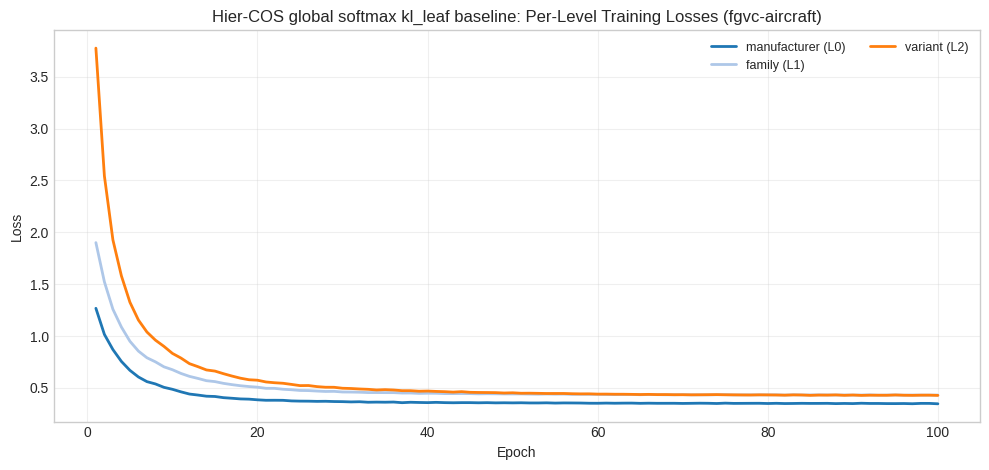

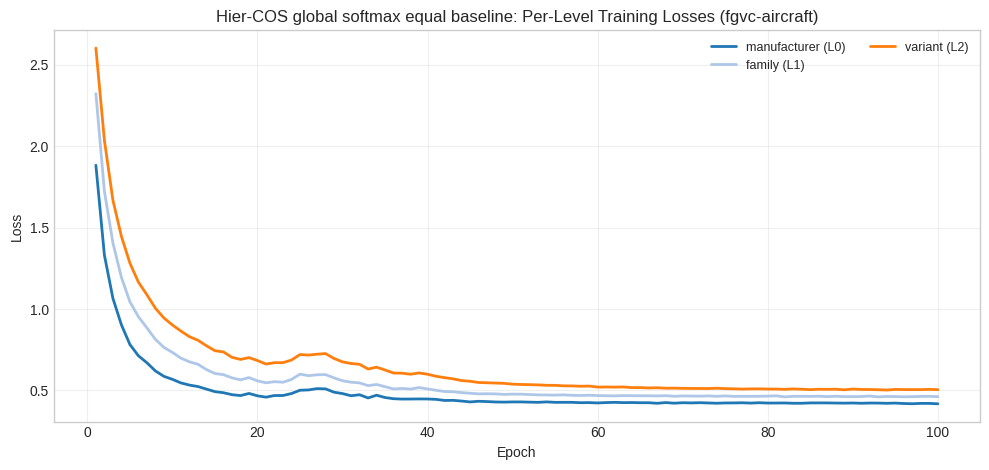

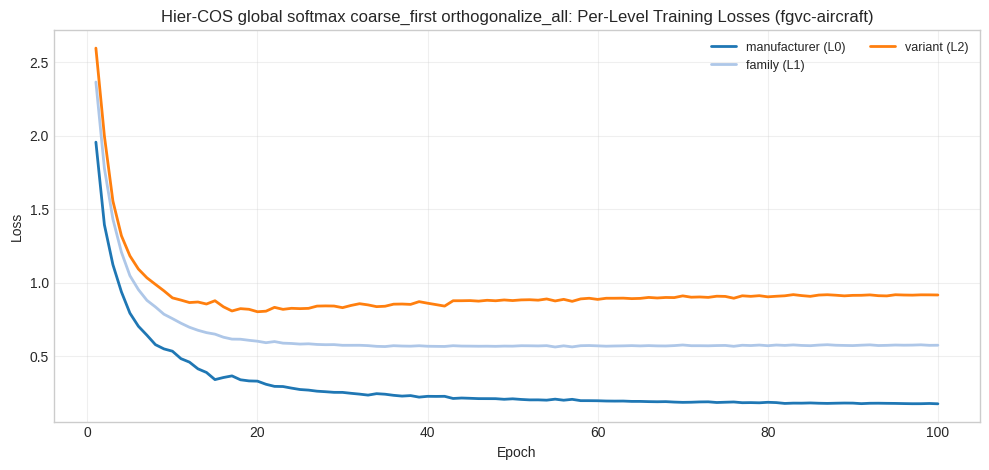

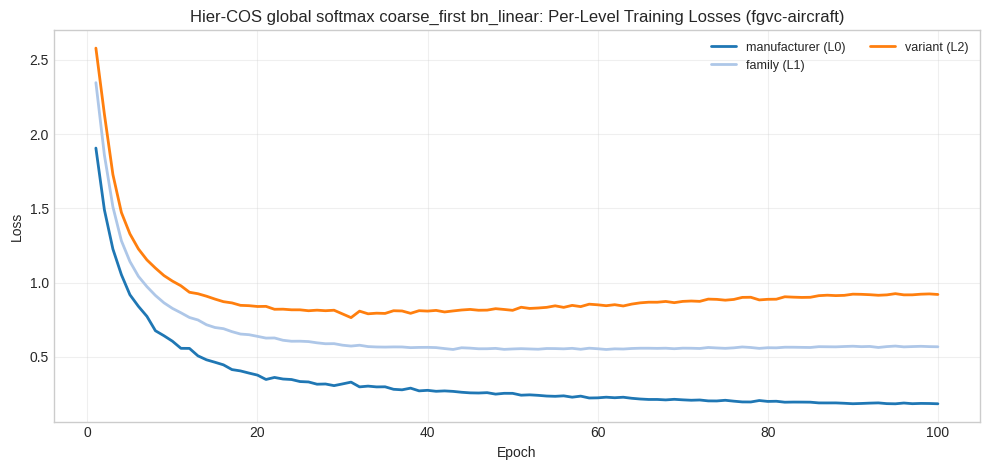

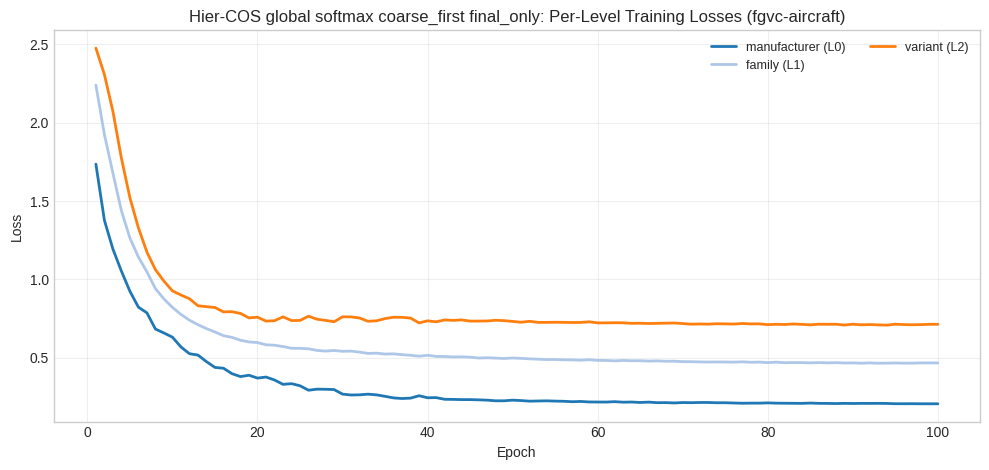

In [7]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and optional projection diagnostics stored in `train_metrics` for each epoch.

For Hier-COS, many of these metrics are available only in CE/diagnostic-focused runs. If unavailable, corresponding plots are skipped automatically.


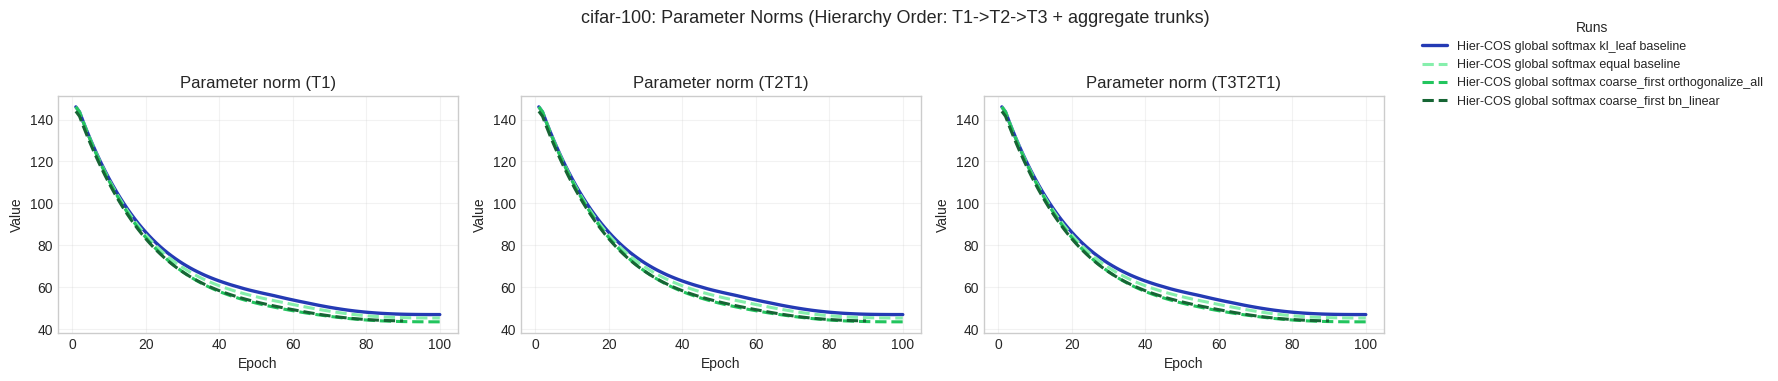

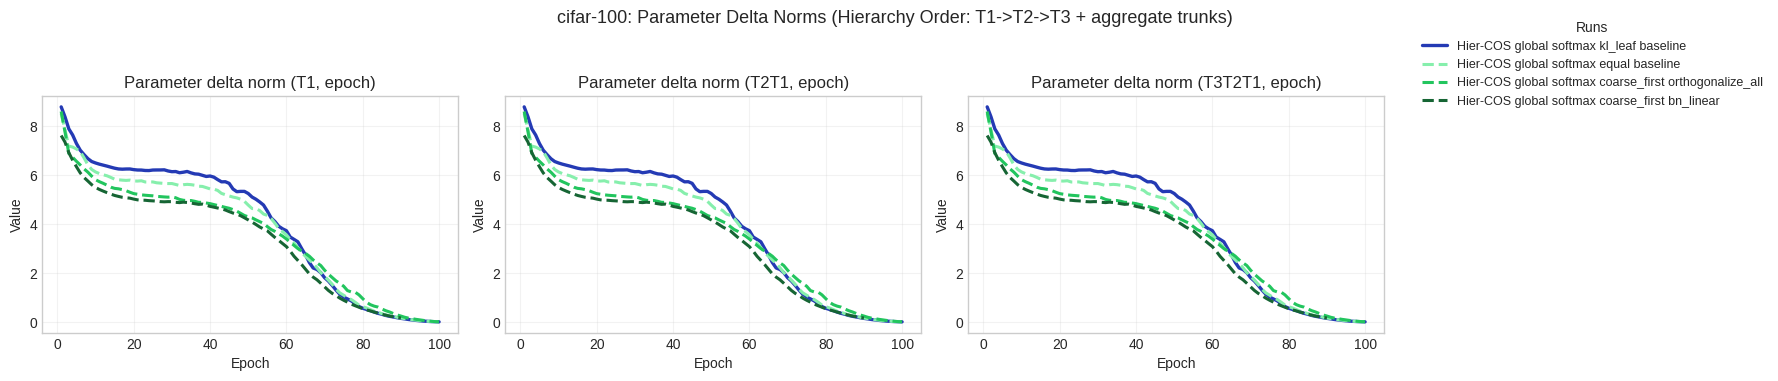

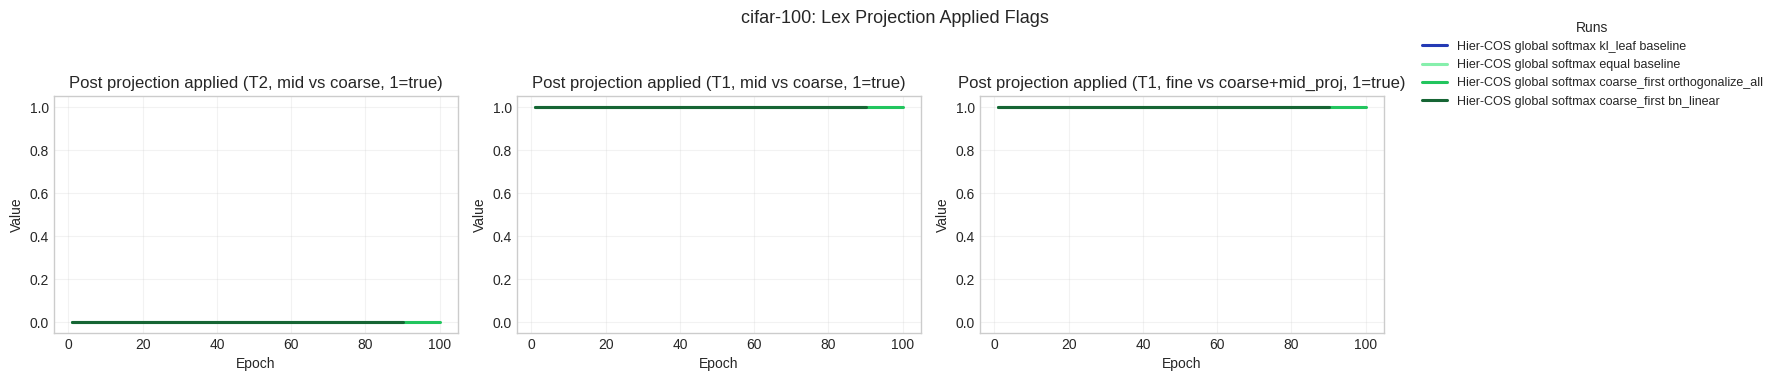

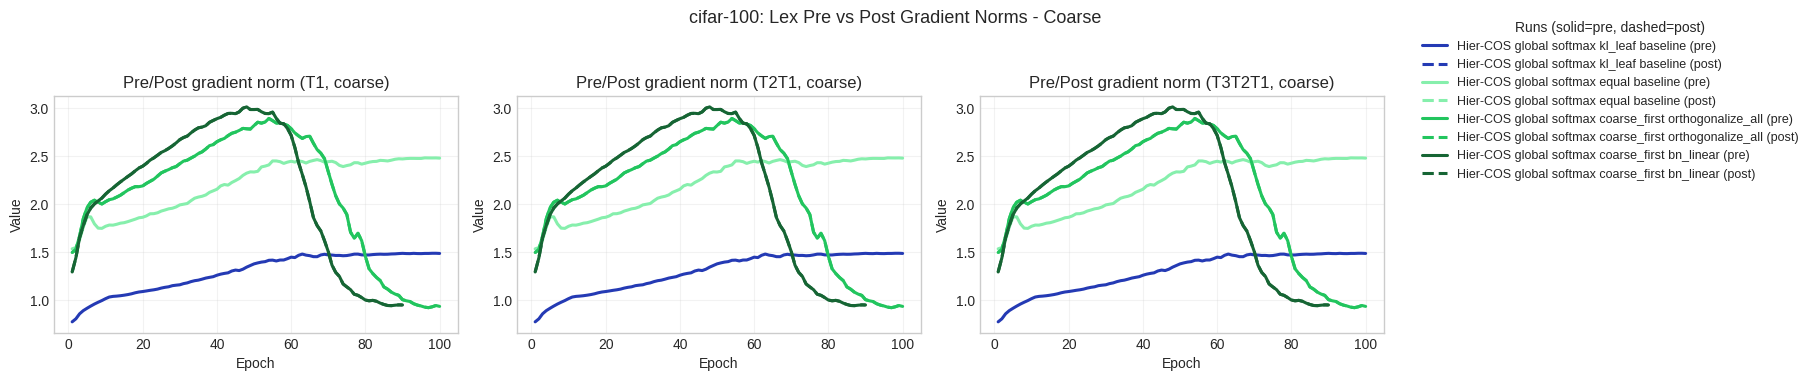

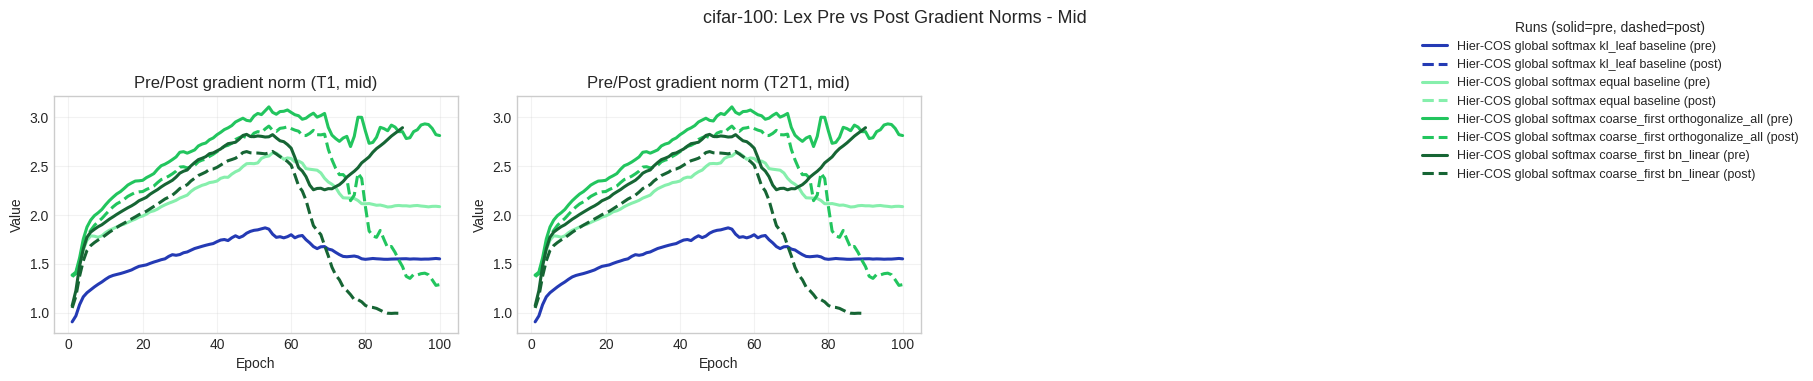

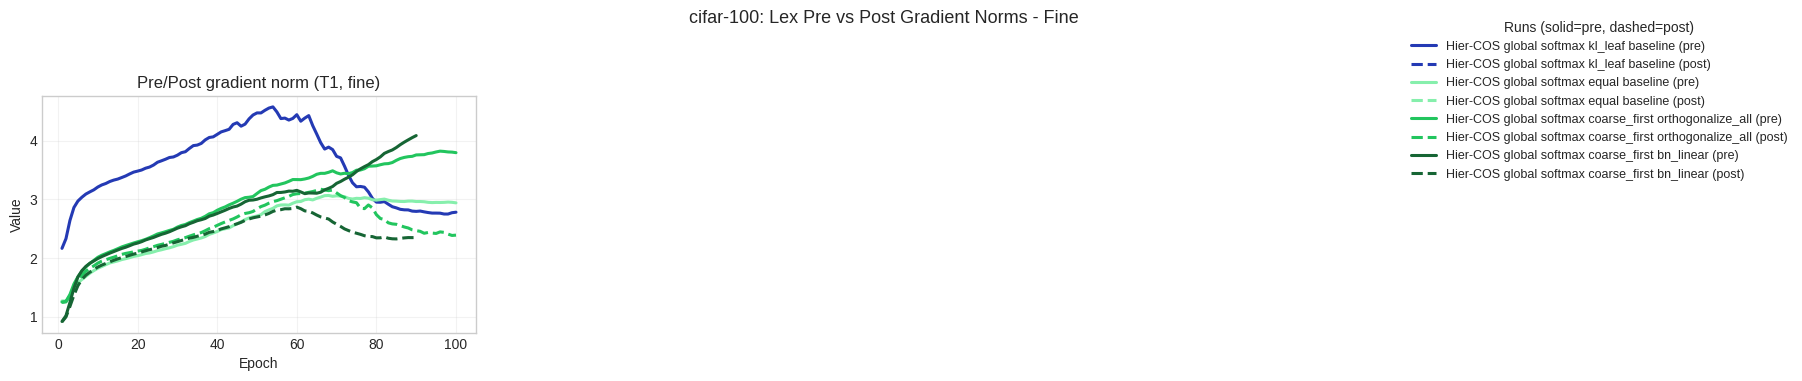

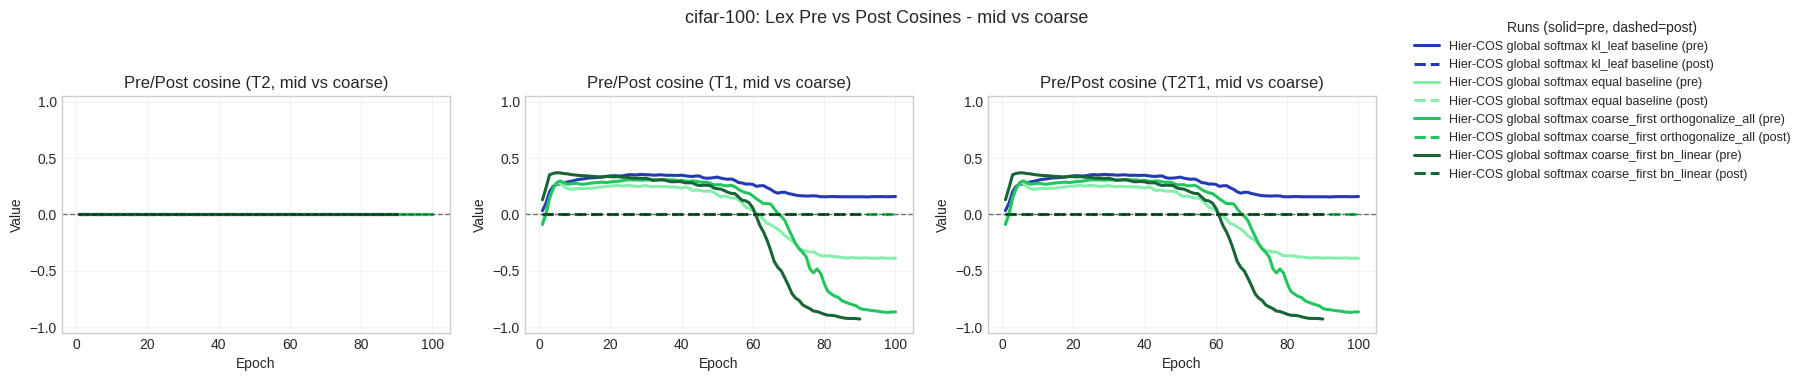

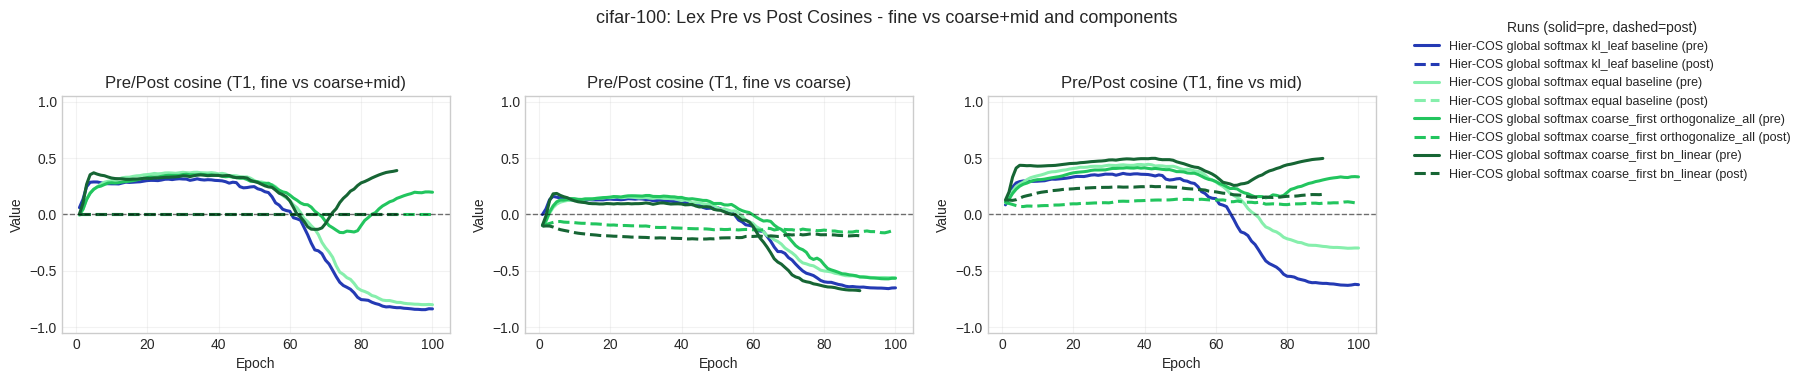

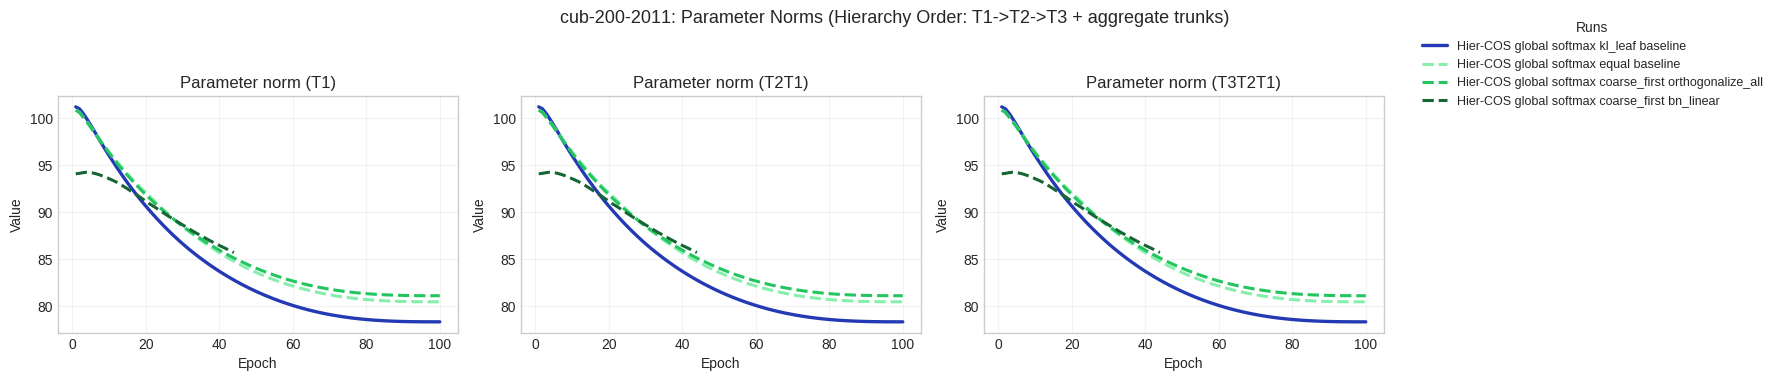

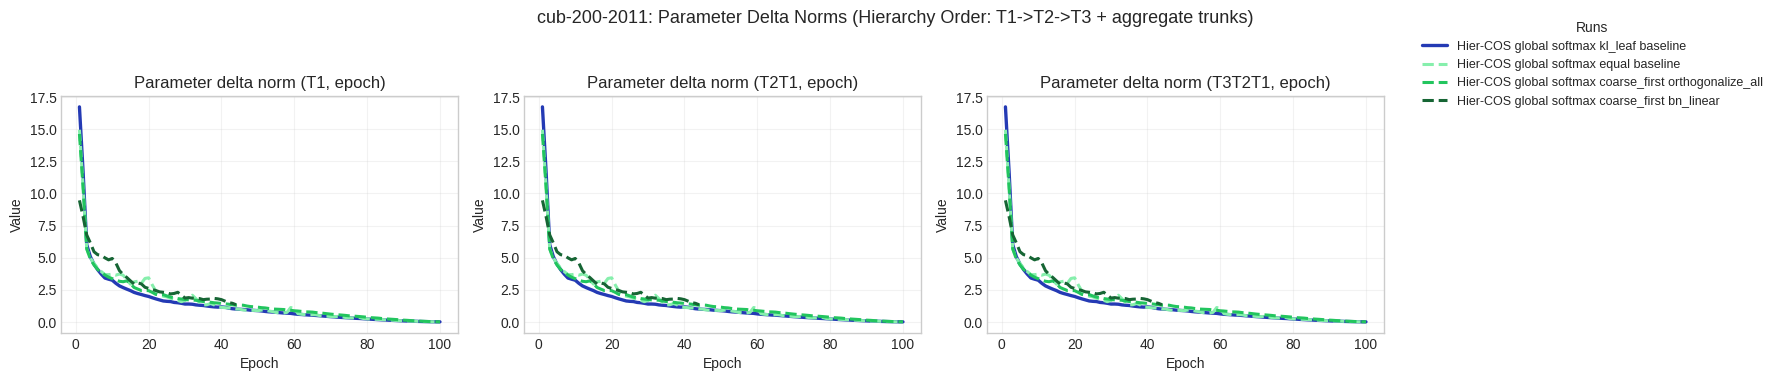

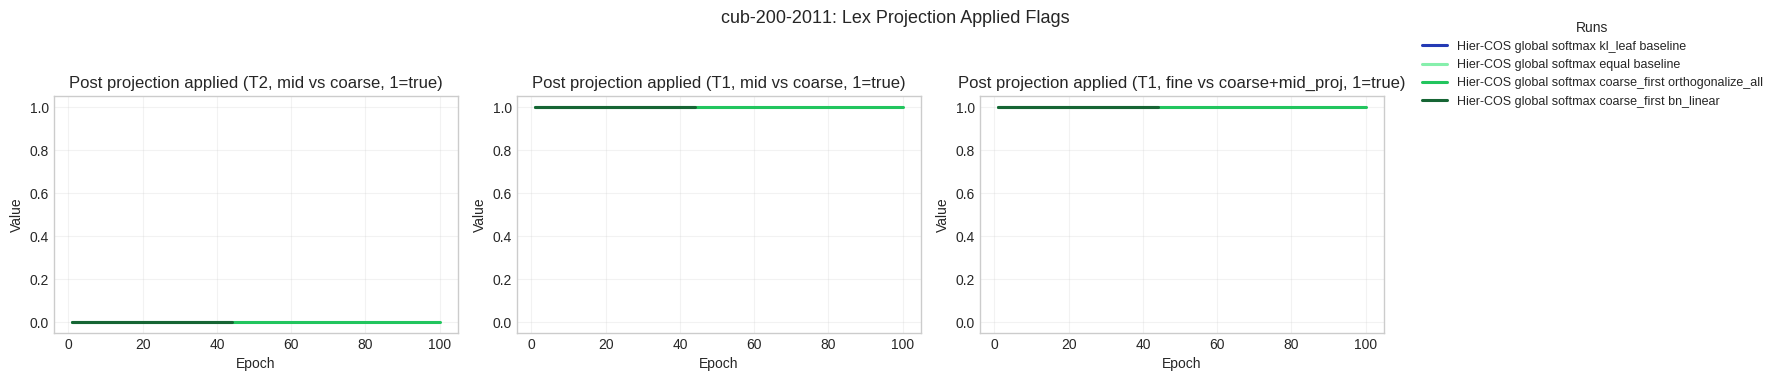

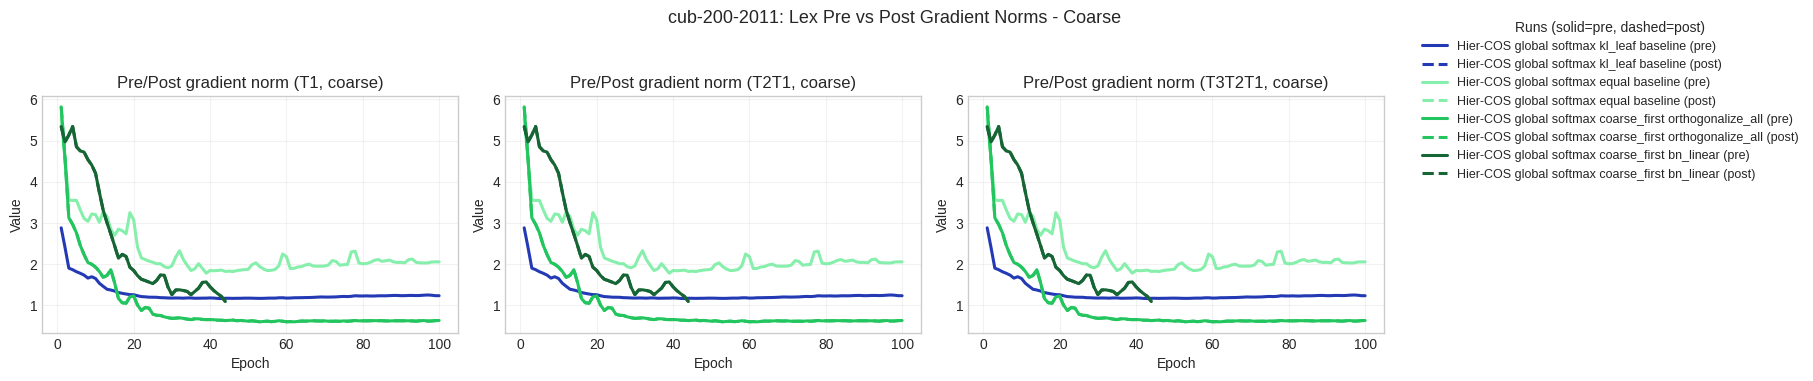

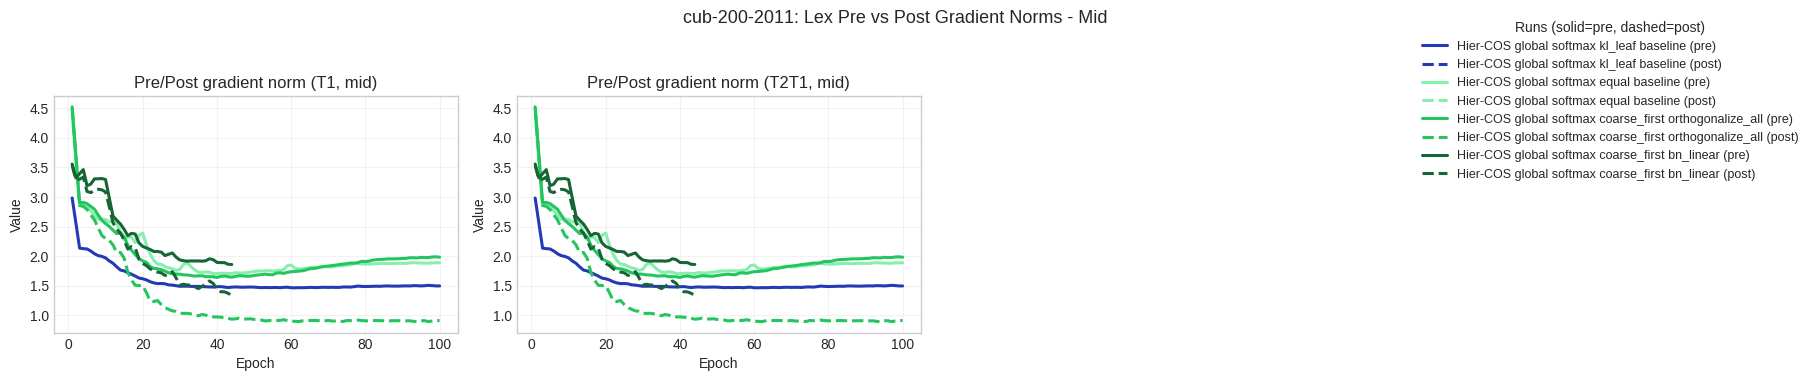

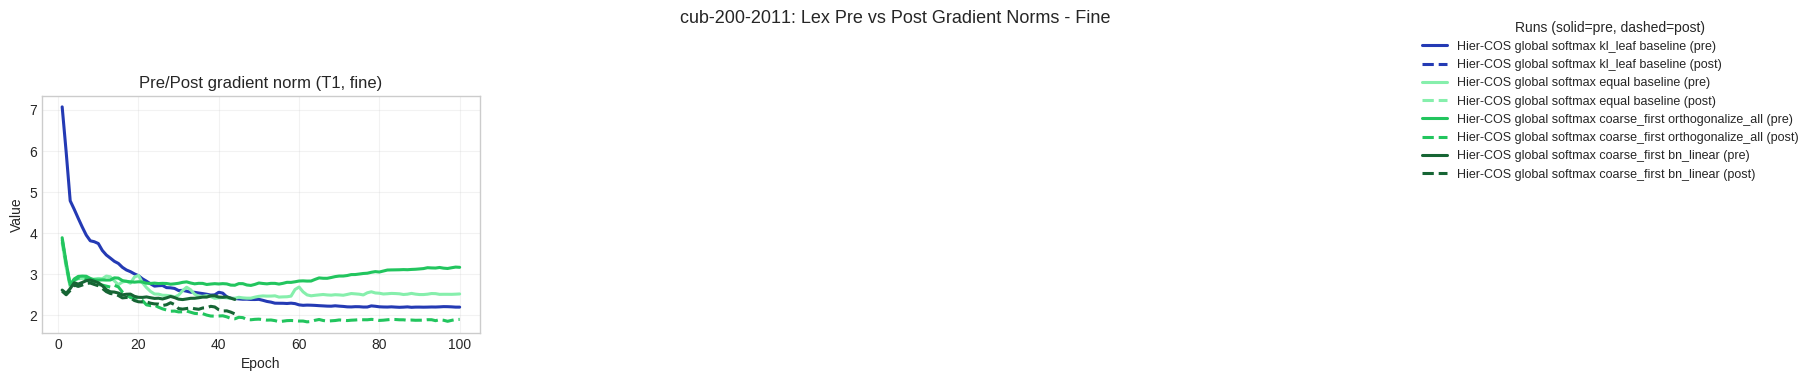

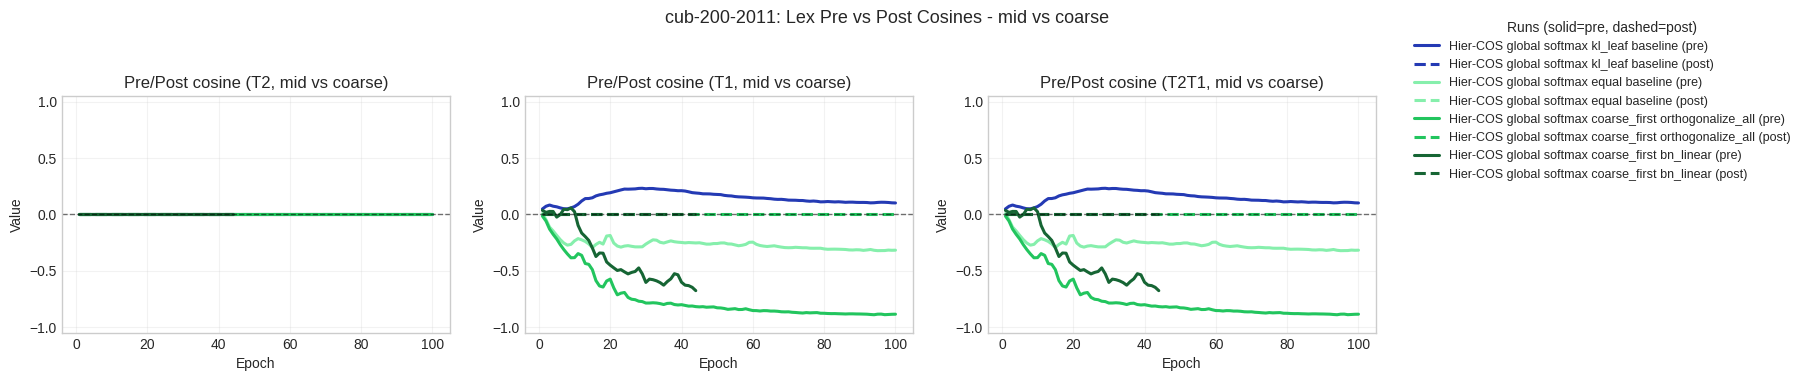

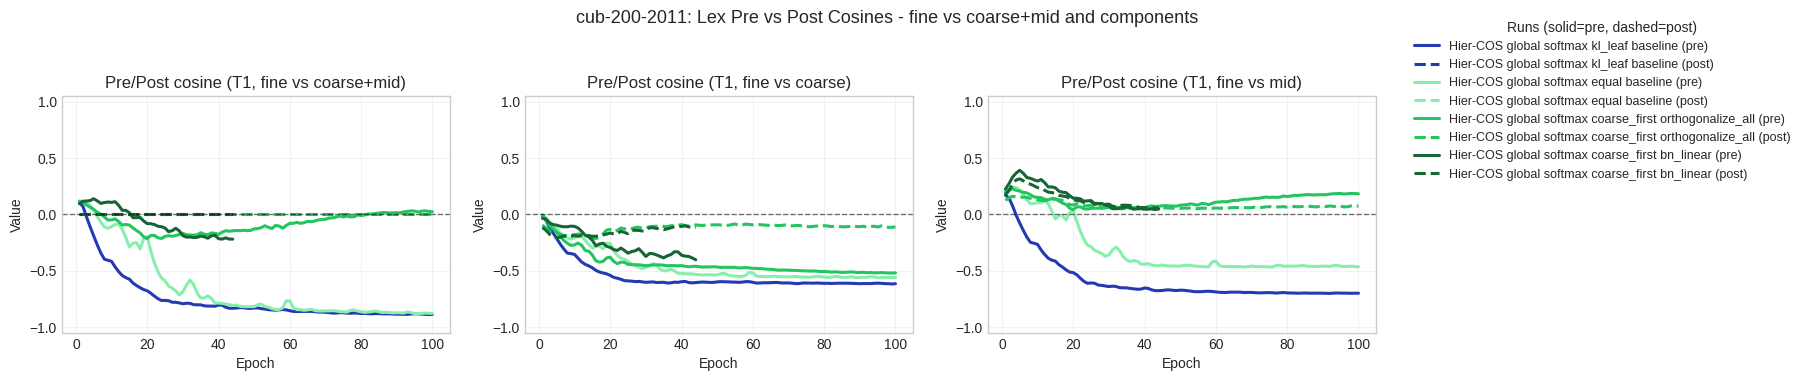

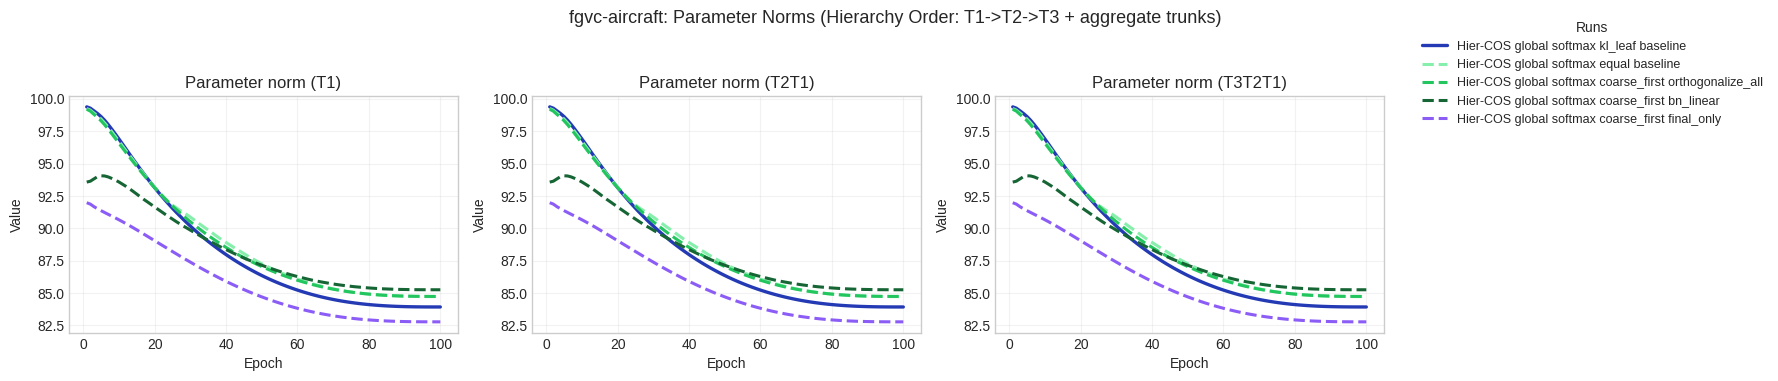

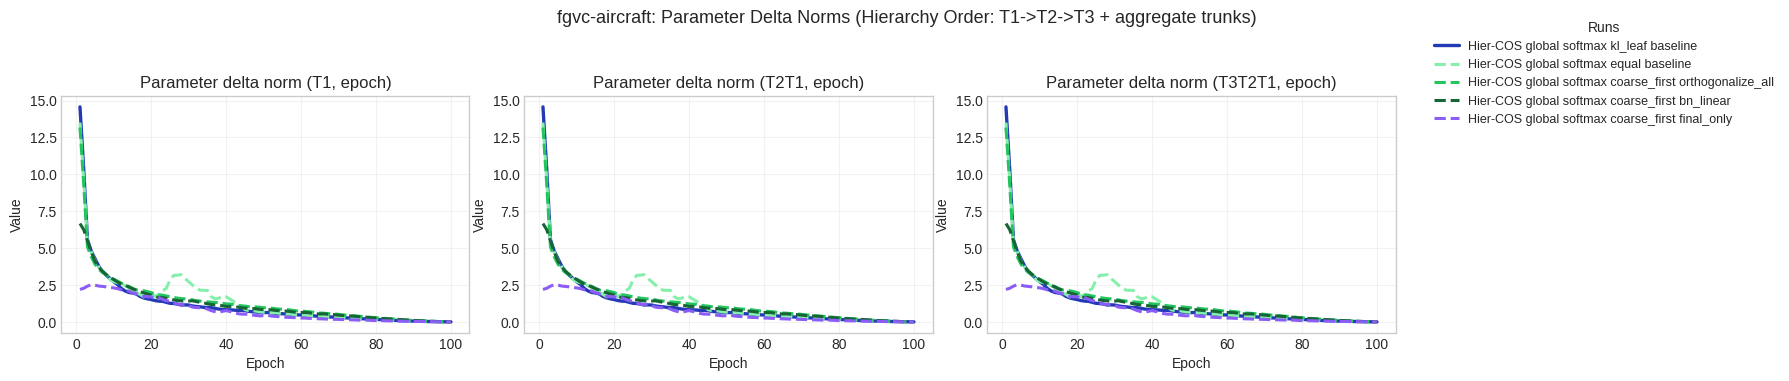

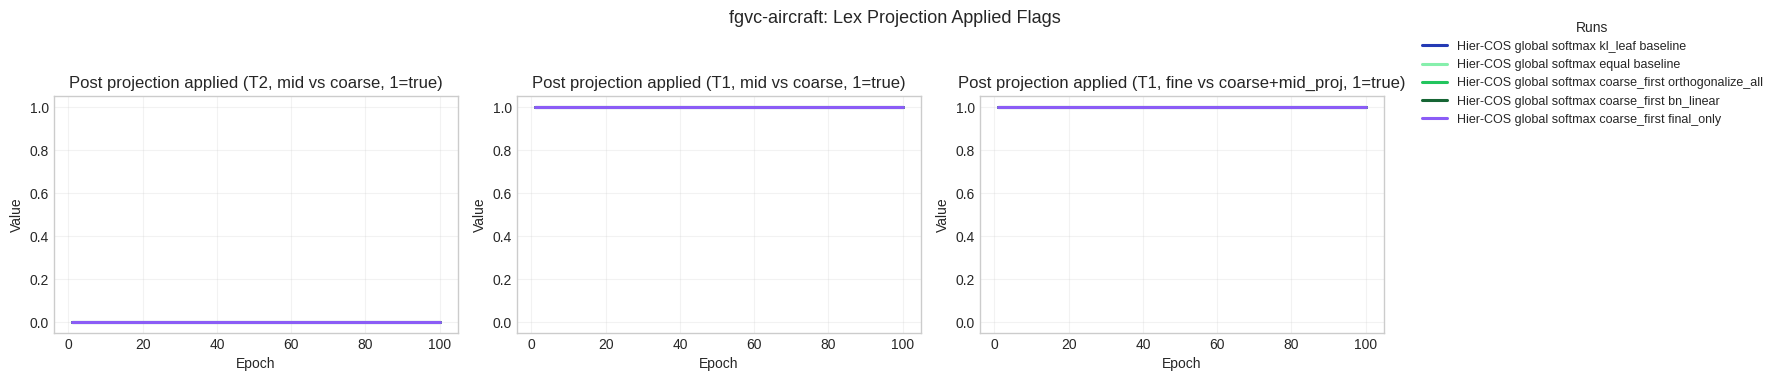

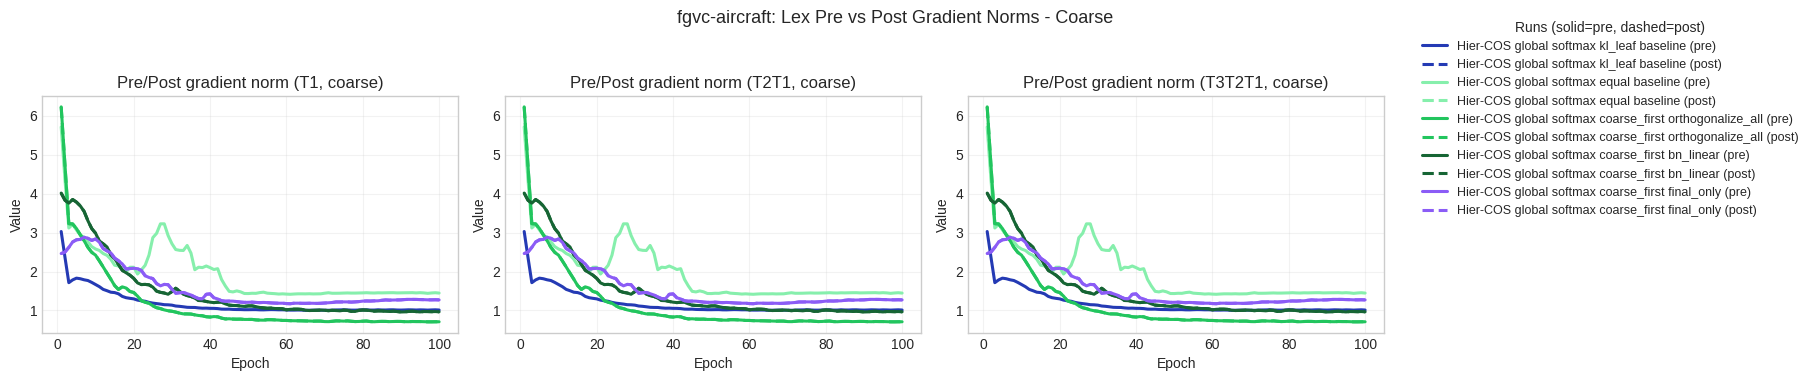

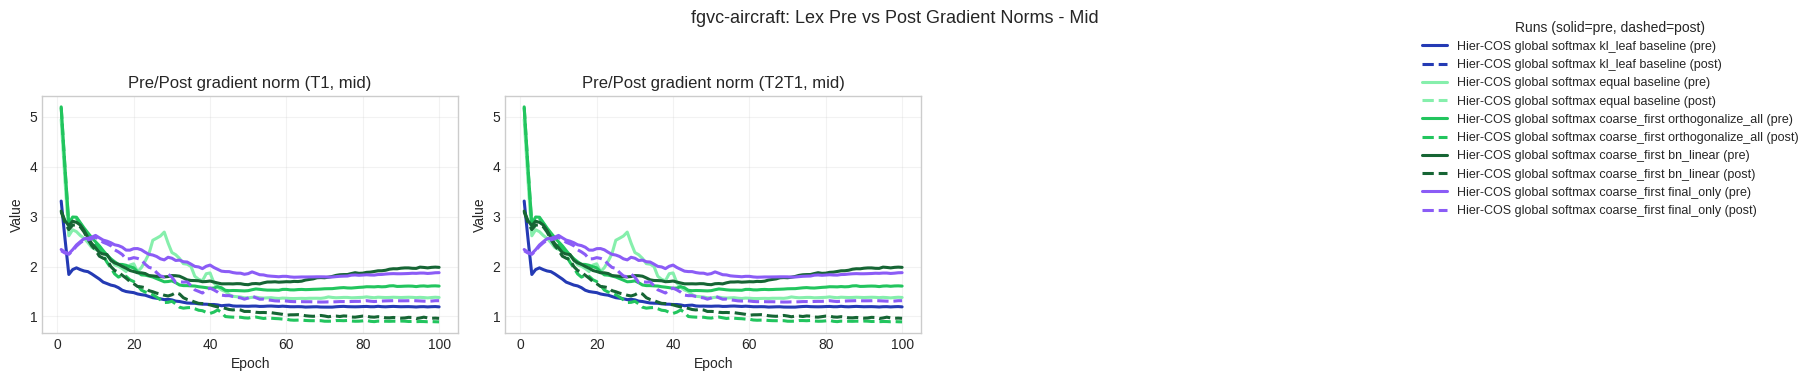

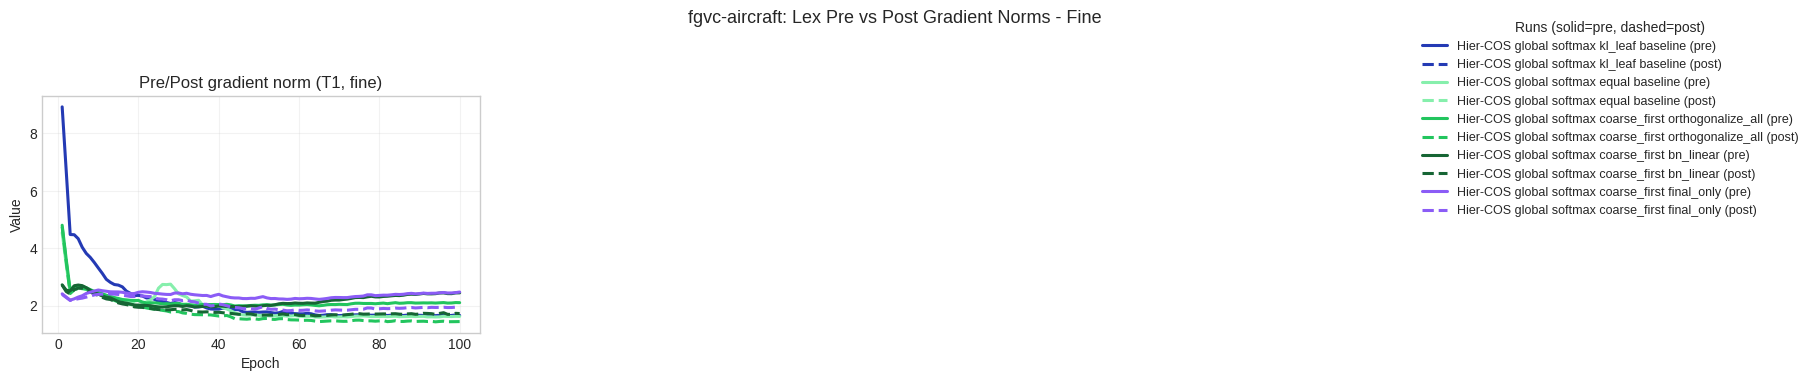

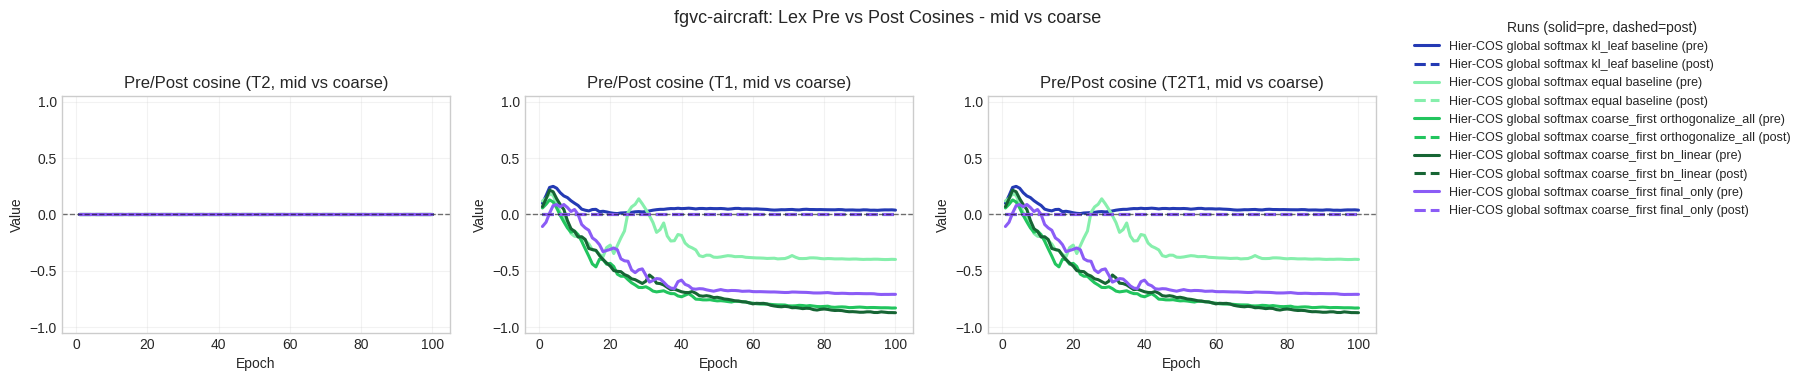

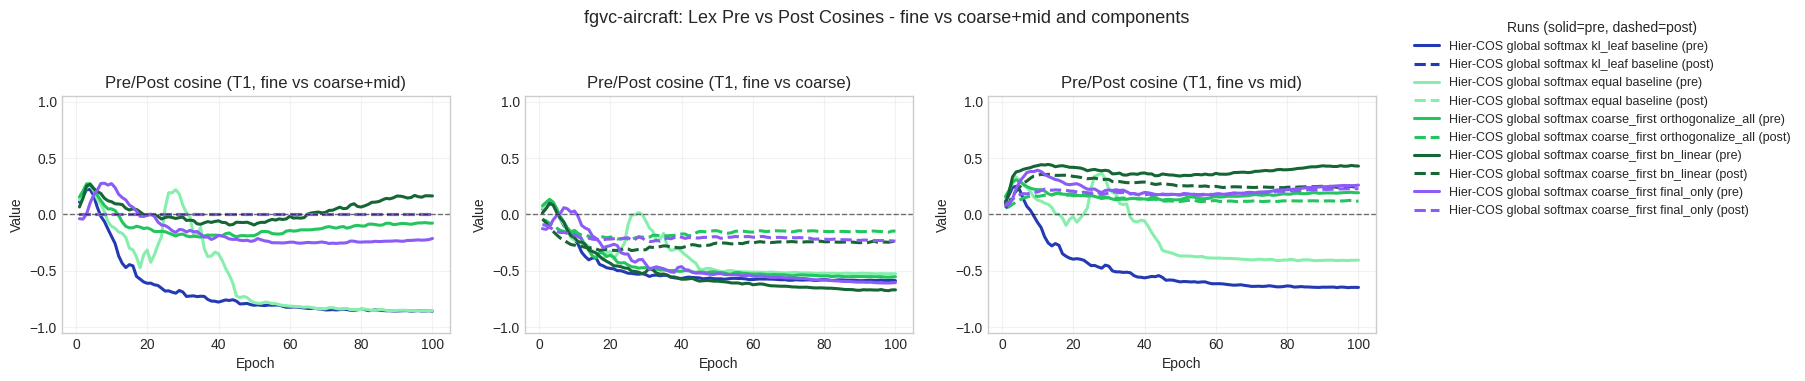

In [8]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

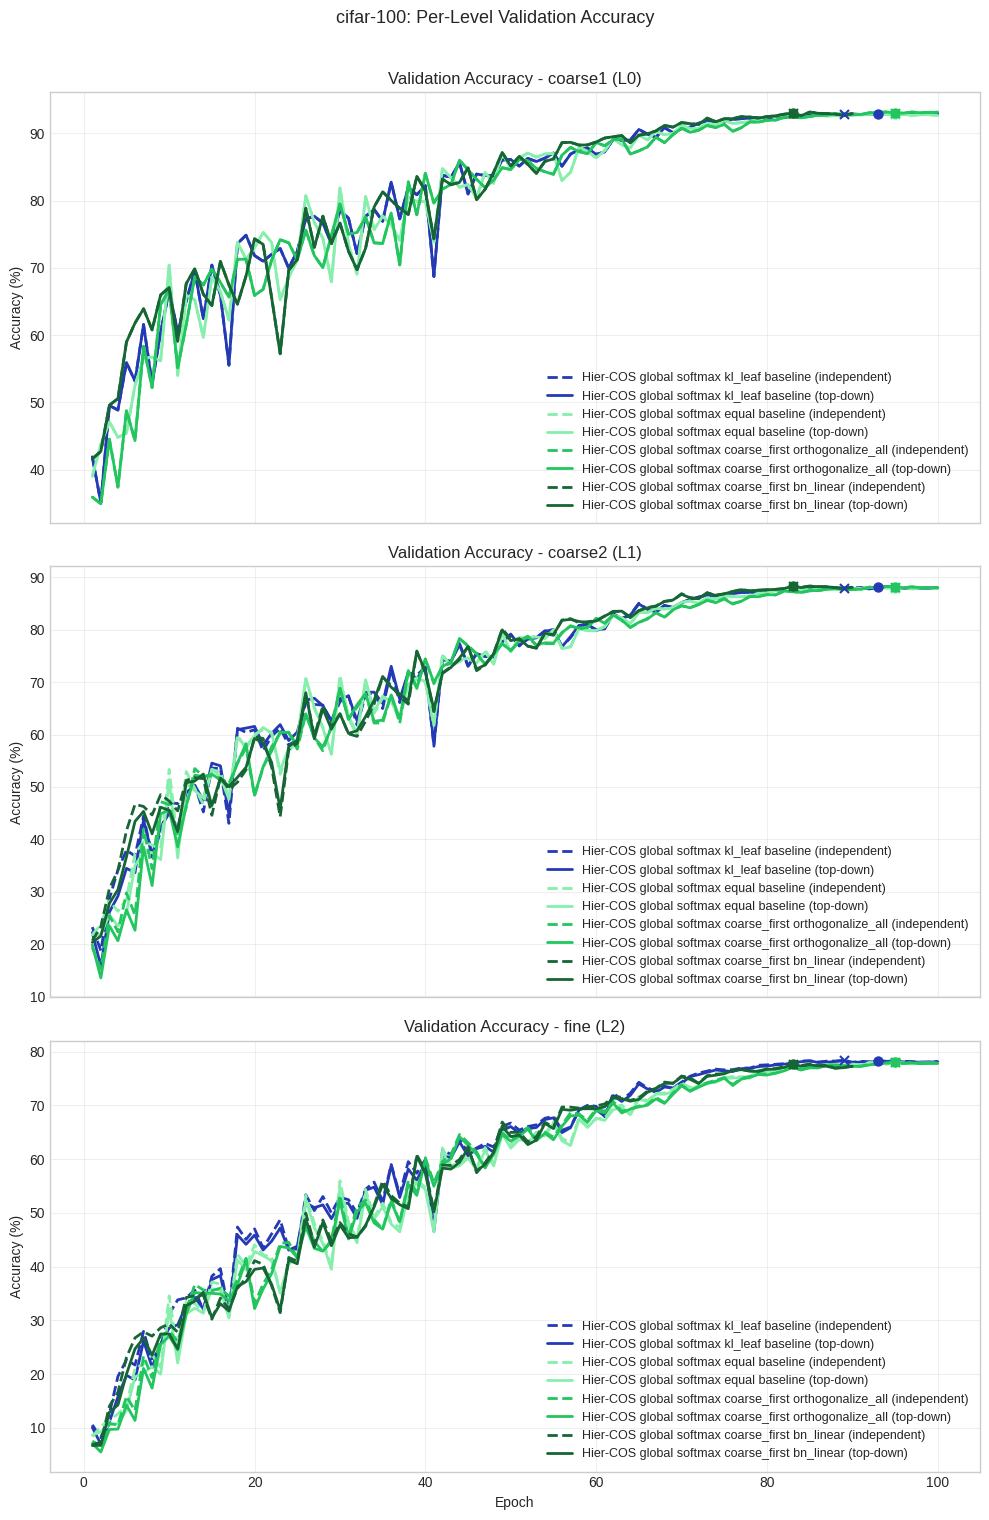

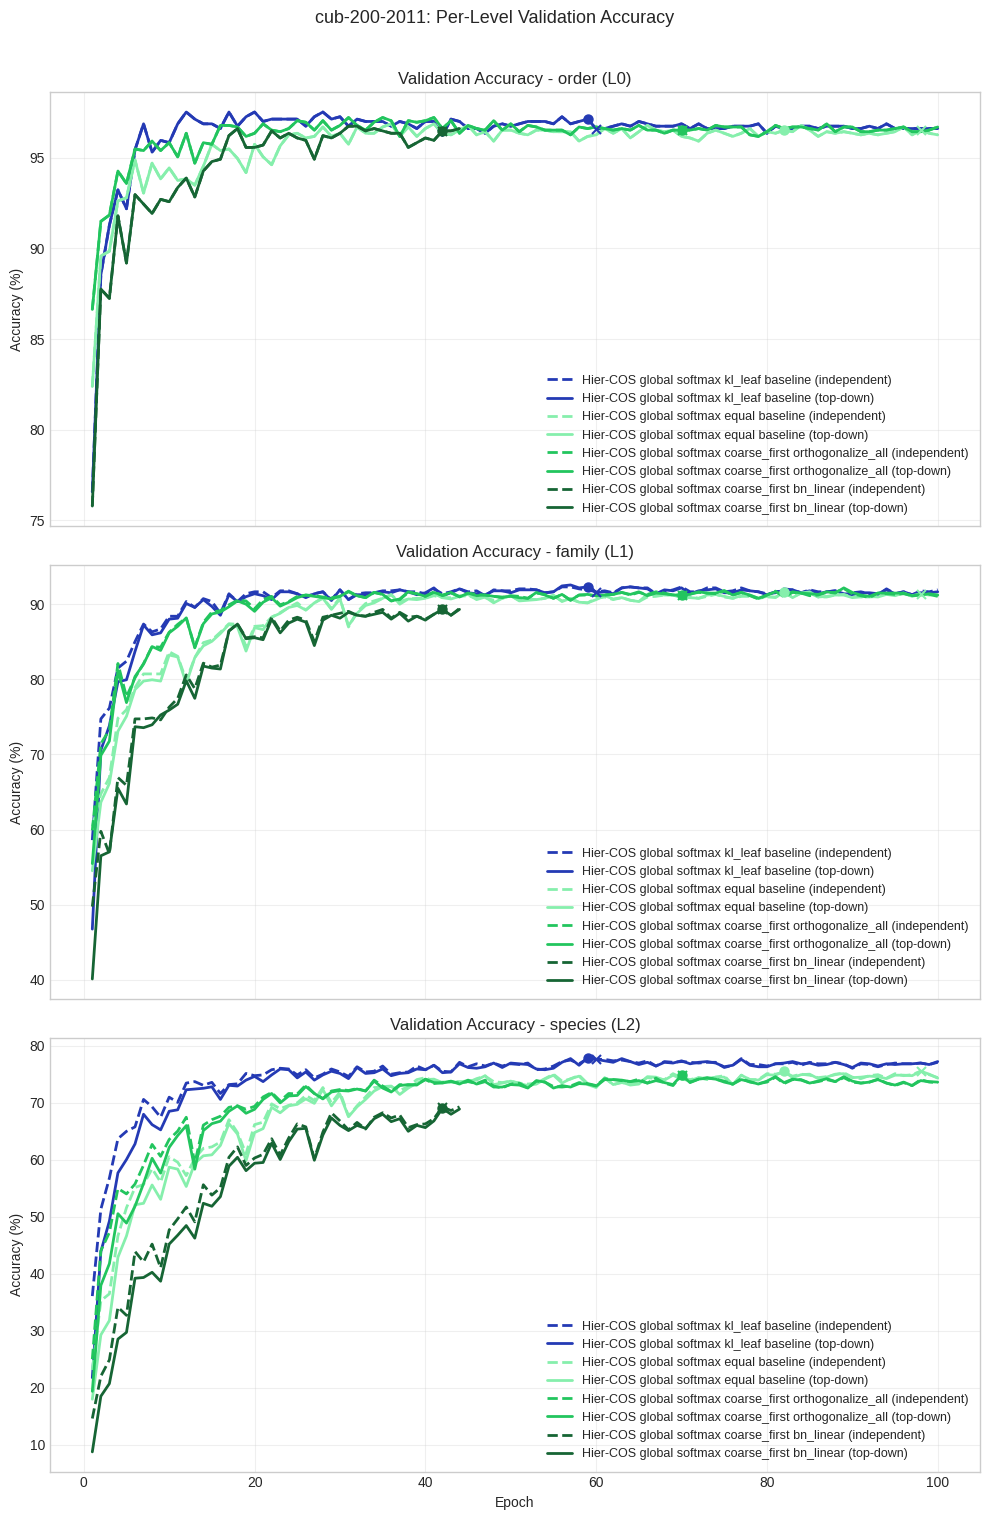

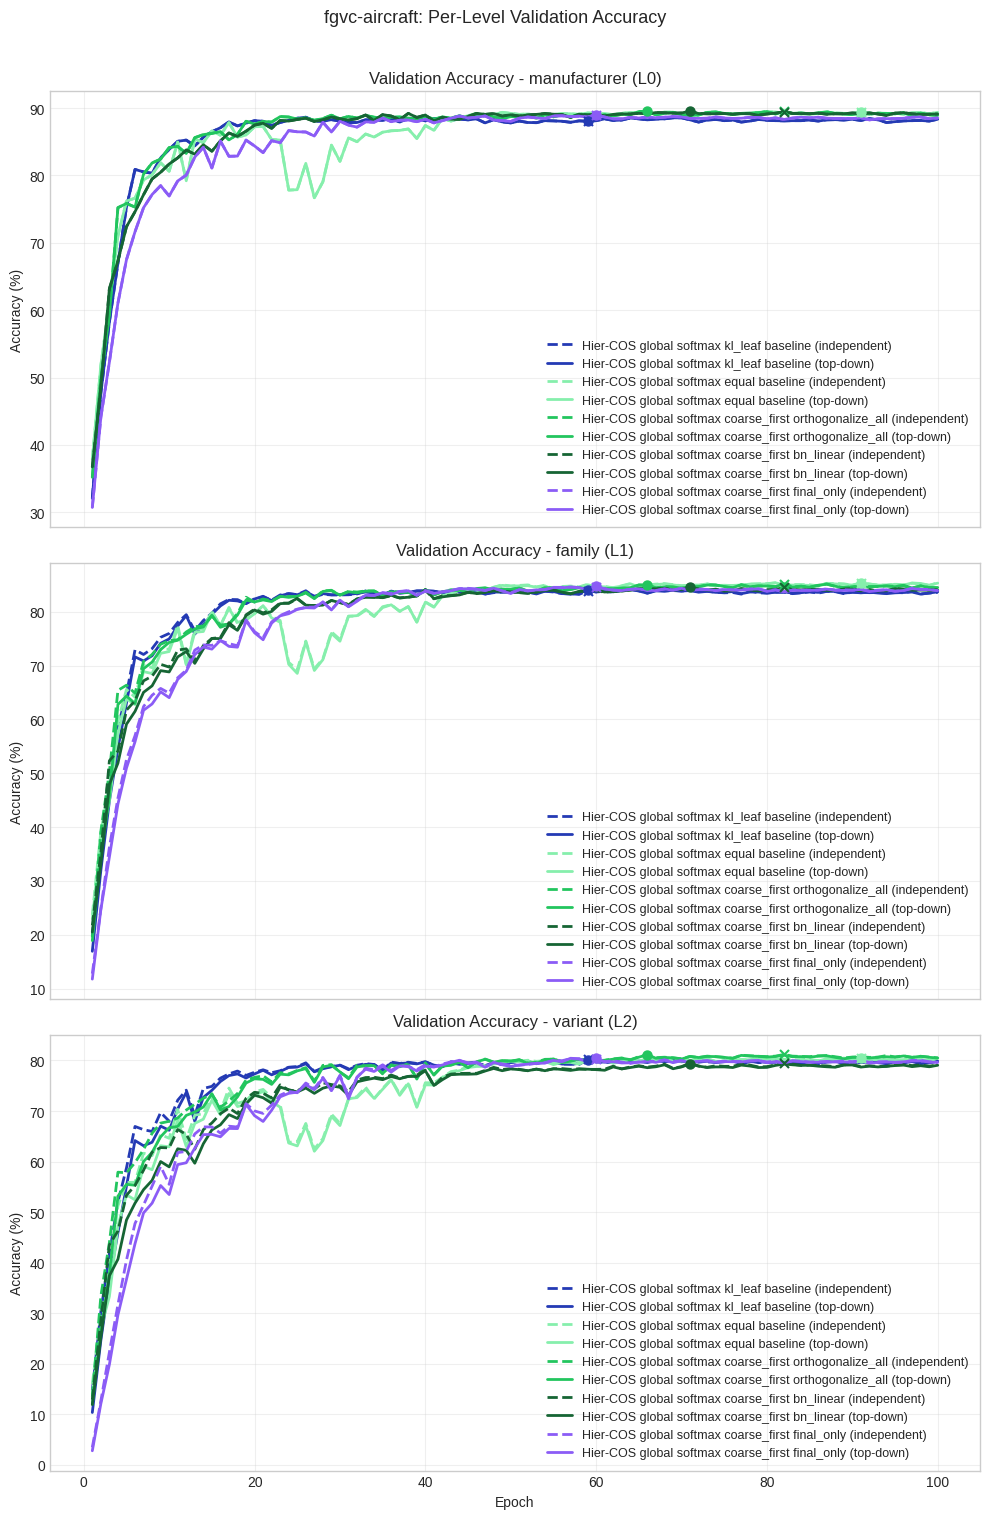

In [9]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset (typically the `kl_reg` baseline).


In [10]:
analysis.show_final_test_tables()


### Dataset: `cifar-100`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline | Hier-COS global softmax equal baseline | Hier-COS global softmax coarse_first orthogonalize_all | Hier-COS global softmax coarse_first bn_linear |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 93/89 | 95/95 | 95/95 | 83/83 |
| FPA independent ↑ | **77.60%** | 76.73% (-0.87 pp) | <u>77.52% (-0.08 pp)</u> | n/a |
| FPA top-down ↑ | **78.04%** | 76.90% (-1.14 pp) | <u>77.67% (-0.37 pp)</u> | n/a |
| wAP independent ↑ | **80.07%** | 79.40% (-0.67 pp) | <u>80.01% (-0.07 pp)</u> | n/a |
| wAP top-down ↑ | **80.30%** | 79.37% (-0.93 pp) | <u>80.01% (-0.29 pp)</u> | n/a |
| TICE independent ↓ | 1.09% | <u>0.71% (-0.38 pp)</u> | **0.50% (-0.59 pp)** | n/a |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | n/a |
| AHD independent ↓ | <u>0.445</u> | 0.450 (+0.005) | **0.439 (-0.006)** | n/a |
| AHD top-down ↓ | **0.433** | 0.448 (+0.014) | <u>0.437 (+0.004)</u> | n/a |
| Acc independent coarse1 (L0) ↑ | 91.28% | <u>91.51% (+0.23 pp)</u> | **91.54% (+0.26 pp)** | n/a |
| Acc top-down coarse1 (L0) ↑ | **91.55%** | 91.51% (-0.04 pp) | <u>91.54% (-0.01 pp)</u> | n/a |
| Acc independent coarse2 (L1) ↑ | 86.79% | <u>86.87% (+0.08 pp)</u> | **87.11% (+0.32 pp)** | n/a |
| Acc top-down coarse2 (L1) ↑ | <u>87.07%</u> | 86.84% (-0.23 pp) | **87.09% (+0.02 pp)** | n/a |
| Acc independent fine (L2) ↑ | **77.83%** | 76.94% (-0.89 pp) | <u>77.66% (-0.17 pp)</u> | n/a |
| Acc top-down fine (L2) ↑ | **78.04%** | 76.90% (-1.14 pp) | <u>77.67% (-0.37 pp)</u> | n/a |

### Dataset: `cub-200-2011`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline | Hier-COS global softmax equal baseline | Hier-COS global softmax coarse_first orthogonalize_all | Hier-COS global softmax coarse_first bn_linear |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 59/60 | 82/98 | 70/70 | 42/42 |
| FPA independent ↑ | **76.48%** | <u>74.39% (-2.08 pp)</u> | 74.24% (-2.24 pp) | n/a |
| FPA top-down ↑ | **76.22%** | <u>74.57% (-1.65 pp)</u> | 74.31% (-1.91 pp) | n/a |
| wAP independent ↑ | **79.84%** | 77.97% (-1.87 pp) | <u>78.04% (-1.80 pp)</u> | n/a |
| wAP top-down ↑ | **79.49%** | <u>78.03% (-1.46 pp)</u> | 77.98% (-1.51 pp) | n/a |
| TICE independent ↓ | 0.71% | **0.38% (-0.33 pp)** | <u>0.47% (-0.24 pp)</u> | n/a |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | n/a |
| AHD independent ↓ | **0.356** | 0.395 (+0.039) | <u>0.379 (+0.023)</u> | n/a |
| AHD top-down ↓ | **0.361** | 0.389 (+0.028) | <u>0.378 (+0.017)</u> | n/a |
| Acc independent order (L0) ↑ | **97.12%** | 96.37% (-0.75 pp) | <u>97.10% (-0.02 pp)</u> | n/a |
| Acc top-down order (L0) ↑ | <u>96.91%</u> | 96.55% (-0.36 pp) | **97.10% (+0.19 pp)** | n/a |
| Acc independent family (L1) ↑ | **90.89%** | 89.84% (-1.04 pp) | <u>90.80% (-0.09 pp)</u> | n/a |
| Acc top-down family (L1) ↑ | <u>90.76%</u> | 89.95% (-0.82 pp) | **90.80% (+0.03 pp)** | n/a |
| Acc independent species (L2) ↑ | **76.61%** | <u>74.51% (-2.10 pp)</u> | 74.38% (-2.24 pp) | n/a |
| Acc top-down species (L2) ↑ | **76.22%** | <u>74.57% (-1.65 pp)</u> | 74.31% (-1.91 pp) | n/a |

### Dataset: `fgvc-aircraft`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline | Hier-COS global softmax equal baseline | Hier-COS global softmax coarse_first orthogonalize_all | Hier-COS global softmax coarse_first bn_linear | Hier-COS global softmax coarse_first final_only |
|---|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 59/59 | 91/91 | 66/82 | 71/82 | 60/60 |
| FPA independent ↑ | 80.20% | <u>80.32% (+0.12 pp)</u> | **81.31% (+1.11 pp)** | 80.23% (+0.03 pp) | 79.24% (-0.96 pp) |
| FPA top-down ↑ | 80.41% | <u>80.47% (+0.06 pp)</u> | **81.07% (+0.66 pp)** | 79.96% (-0.45 pp) | 79.30% (-1.11 pp) |
| wAP independent ↑ | 83.08% | 83.49% (+0.41 pp) | **84.27% (+1.19 pp)** | <u>83.55% (+0.47 pp)</u> | 82.47% (-0.61 pp) |
| wAP top-down ↑ | 83.14% | <u>83.48% (+0.33 pp)</u> | **83.86% (+0.71 pp)** | 83.15% (+0.01 pp) | 82.41% (-0.73 pp) |
| TICE independent ↓ | 1.35% | 0.78% (-0.57 pp) | **0.42% (-0.93 pp)** | 0.99% (-0.36 pp) | <u>0.54% (-0.81 pp)</u> |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 0.467 | 0.452 (-0.015) | **0.429 (-0.038)** | <u>0.451 (-0.016)</u> | 0.480 (+0.013) |
| AHD top-down ↓ | 0.462 | <u>0.450 (-0.012)</u> | **0.439 (-0.023)** | 0.457 (-0.005) | 0.479 (+0.017) |
| Acc independent manufacturer (L0) ↑ | 88.82% | 89.30% (+0.48 pp) | **89.93% (+1.11 pp)** | <u>89.51% (+0.69 pp)</u> | 88.61% (-0.21 pp) |
| Acc top-down manufacturer (L0) ↑ | 88.82% | <u>89.30% (+0.48 pp)</u> | **89.69% (+0.87 pp)** | 89.27% (+0.45 pp) | 88.61% (-0.21 pp) |
| Acc independent family (L1) ↑ | 84.44% | <u>85.31% (+0.87 pp)</u> | **85.94% (+1.50 pp)** | 85.28% (+0.84 pp) | 84.16% (-0.27 pp) |
| Acc top-down family (L1) ↑ | 84.62% | <u>85.28% (+0.66 pp)</u> | **85.34% (+0.72 pp)** | 85.10% (+0.48 pp) | 84.19% (-0.42 pp) |
| Acc independent variant (L2) ↑ | 80.41% | 80.47% (+0.06 pp) | **81.40% (+0.99 pp)** | <u>80.56% (+0.15 pp)</u> | 79.45% (-0.96 pp) |
| Acc top-down variant (L2) ↑ | 80.41% | <u>80.47% (+0.06 pp)</u> | **81.07% (+0.66 pp)** | 79.96% (-0.45 pp) | 79.30% (-1.11 pp) |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
